# Notebook 4 — Weather, Demand, and Renewables

## Overview

This notebook investigates how weather conditions translate into Alberta electricity demand, wind generation, solar generation, and net load.

Notebook 2 established that net load and available system margin are important indicators of physical system tightness. Notebook 4 moves upstream of those results. It asks how temperature, wind, irradiance, cloud cover, snow, and compound weather conditions create the demand and renewable-output states observed by the power system.

The notebook examines:

- temperature and electricity-demand formation;
- wind speed and wind-generation availability;
- irradiance, clouds, snow, and solar generation;
- renewable ramps and persistent low-output conditions;
- compound weather conditions associated with extreme net load; and
- the distinction between explanatory weather observations and forecast-eligible weather inputs.

The analysis is descriptive and contemporaneous. ERA5 values represent observed reanalysis weather rather than operational weather forecasts. Actual load and renewable generation are realized outcomes and are not automatically forecast eligible.

The notebook does not repeat Notebook 2’s scarcity analysis, Notebook 5’s calendar and price-memory analysis, or the predictive modelling assigned to Notebooks 6–8.

## 1. Imports and definitions

This section loads the canonical weather and market data, checks coverage and reporting boundaries, and defines the weather-to-output measures used below.

### 1.1 Imports and data

The notebook uses the canonical hourly master dataset produced by the project pipeline. The `master` DataFrame remains authoritative, while Notebook 4 variables are stored separately in `weather_features`.

The study period covers Alberta operating years 2015–2025.

In [1]:
# ---------------------------------------------------------------------
# Configure imports and load the canonical master dataset
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from config import MASTER_PARQUET, RANDOM_SEED

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

np.random.seed(RANDOM_SEED)

master = pd.read_parquet(MASTER_PARQUET)

print(
    f'Canonical master loaded: '
    f'{master.shape[0]:,} rows x '
    f'{master.shape[1]:,} columns'
)

Canonical master loaded: 100,033 rows x 494 columns


### 1.2 Required inputs

Timestamp integrity, coverage, reporting boundaries, and physical units are audited before the analysis begins.

The weather inputs have two distinct constructions:

- **Load-weighted weather** combines regional weather using actual hourly regional load shares.
- **Renewable capacity-weighted weather** combines project-level weather using the historically active wind or solar fleet.

Load-weighted weather is useful for historical explanation, but its actual same-hour regional weights are not directly forecast eligible. Renewable weather fields are also observed ERA5 reanalysis and must eventually be replaced by operational weather forecasts.

In [2]:
# ---------------------------------------------------------------------
# Define study period and required inputs
# ---------------------------------------------------------------------

STUDY_START_YEAR = 2015
STUDY_END_YEAR = 2025

ALBERTA_TIMEZONE = 'America/Edmonton'

TEMPERATURE_BIN_WIDTH_C = 2
WIND_SPEED_BIN_WIDTH_MS = 1
SOLAR_RADIATION_BIN_WIDTH_WM2 = 50

MINIMUM_BIN_HOURS = 100
MINIMUM_STATE_HOURS = 100

EXTREME_NET_LOAD_PERCENTILE = 0.99

REGIONAL_LOAD_COLUMNS = [
    "calgary_load_mw",
    "central_load_mw",
    "edmonton_load_mw",
    "northeast_load_mw",
    "northwest_load_mw",
    "south_load_mw",
]

LOAD_WEATHER_COLUMNS = [
    "load_weighted_temperature_c",
    "load_temperature_spatial_std_c",
    "load_temperature_min_c",
    "load_temperature_max_c",
    "load_weighted_relative_humidity_pct",
    "load_weighted_wind_chill_c",
    "load_weighted_heat_index_c",
    "load_weighted_wetbulb_c",
    "load_temperature_change_1h_c",
    "load_temperature_change_6h_c",
    "load_temperature_mean_24h_c",
]

WIND_WEATHER_COLUMNS = [
    "wind_capacity_weighted_speed_100m",
    "wind_capacity_weighted_speed_100m_cubed",
    "wind_speed_100m_spatial_std",
    "wind_capacity_weighted_air_density",
    "wind_capacity_weighted_total_cloud_cover",
]

SOLAR_WEATHER_COLUMNS = [
    "solar_capacity_weighted_radiation_wm2",
    "solar_clear_sky_radiation_ratio",
    "solar_capacity_weighted_total_cloud_cover",
    "solar_capacity_weighted_snow_depth",
    "solar_capacity_weighted_temperature_2m",
]

REQUIRED_COLUMNS = [
    "timestamp_utc",
    "timestamp_alberta",
    "local_date",
    "year_alberta",
    "ail_mw",
    "wind_system_generation",
    "wind_system_available",
    "wind_system_capacity",
    "wind_installed_capacity_mw",
    "solar_system_generation",
    "solar_system_available",
    "solar_system_capacity",
    "solar_installed_capacity_mw",
    "hydro_system_generation",
    "hydro_system_available",
    "hydro_system_capacity",
    "hydro_outage",
] + (
    REGIONAL_LOAD_COLUMNS
    + LOAD_WEATHER_COLUMNS
    + WIND_WEATHER_COLUMNS
    + SOLAR_WEATHER_COLUMNS
)

missing_required_columns = sorted(
    set(REQUIRED_COLUMNS) - set(master.columns)
)

if missing_required_columns:
    raise ValueError(
        "Master dataset is missing Notebook 4 columns: "
        f"{missing_required_columns}"
    )

master["timestamp_utc"] = pd.to_datetime(
    master["timestamp_utc"],
    utc=True,
)

master = (
    master
    .sort_values("timestamp_utc")
    .loc[
        master["year_alberta"].between(
            STUDY_START_YEAR,
            STUDY_END_YEAR,
        )
    ]
    .copy()
    .reset_index(drop=True)
)

duplicate_timestamps = int(
    master["timestamp_utc"].duplicated().sum()
)

non_hourly_intervals = int(
    master["timestamp_utc"]
    .diff()
    .iloc[1:]
    .ne(pd.Timedelta(hours=1))
    .sum()
)

if duplicate_timestamps or non_hourly_intervals:
    raise ValueError(
        "Hourly timestamp validation failed: "
        f"duplicates={duplicate_timestamps}, "
        f"non_hourly_intervals={non_hourly_intervals}"
    )

print(
    "Selected period:",
    master["timestamp_alberta"].min(),
    "to",
    master["timestamp_alberta"].max(),
)

Selected period: 2015-01-01 00:00:00-07:00 to 2025-12-31 23:00:00-07:00


### 1.3 Coverage and reporting boundaries

Coverage checks distinguish true missing observations from technology entry, nighttime solar zeros, and other known reporting boundaries.

In [3]:
# ---------------------------------------------------------------------
# Audit annual study-period coverage
# ---------------------------------------------------------------------

study_years = pd.Index(
    range(
        STUDY_START_YEAR,
        STUDY_END_YEAR + 1,
    ),
    name = 'year_alberta',
)

observed_hours = (
    master
    .groupby('year_alberta')
    .size()
    .reindex(study_years, fill_value=0)
)

expected_hours = pd.Series(
    {
        year: len(
            pd.date_range(
                start=f"{year}-01-01",
                end=f"{year + 1}-01-01",
                inclusive="left",
                freq="h",
                tz=ALBERTA_TIMEZONE,
            )
        )
        for year in study_years
    },
    name="expected_hours",
)

expected_hours.index.name = "year_alberta"

annual_coverage = pd.concat(
    [
        expected_hours,
        observed_hours.rename("observed_hours"),
    ],
    axis=1,
)

annual_coverage["unobserved_hours"] = (
    annual_coverage["expected_hours"]
    - annual_coverage["observed_hours"]
)

annual_coverage["coverage_pct"] = (
    annual_coverage["observed_hours"]
    / annual_coverage["expected_hours"]
    * 100
)

display(
    annual_coverage.round(
        {"coverage_pct": 3}
    )
)

,expected_hours,observed_hours,unobserved_hours,coverage_pct
year_alberta,,,,
2015,8760,8760,0,100.0
2016,8784,8784,0,100.0
2017,8760,8760,0,100.0
2018,8760,8760,0,100.0
2019,8760,8760,0,100.0
2020,8784,8784,0,100.0
2021,8760,8760,0,100.0
2022,8760,8760,0,100.0
2023,8760,8760,0,100.0


In [4]:
# ---------------------------------------------------------------------
# Audit weather, load, and renewable reporting coverage
# ---------------------------------------------------------------------

AUDIT_COLUMNS = [
    "ail_mw",
    *LOAD_WEATHER_COLUMNS,
    "wind_system_generation",
    "wind_system_capacity",
    *WIND_WEATHER_COLUMNS,
    "solar_system_generation",
    "solar_system_capacity",
    *SOLAR_WEATHER_COLUMNS,
    "hydro_system_generation",
    "hydro_system_available",
    "hydro_system_capacity",
]

input_audit = pd.DataFrame(
    {
        "missing_hours":
            master[AUDIT_COLUMNS].isna().sum(),

        "coverage_pct":
            master[AUDIT_COLUMNS].notna().mean()
            * 100,

        "first_reported": [
            master.loc[
                master[column].notna(),
                "timestamp_alberta",
            ].min()
            for column in AUDIT_COLUMNS
        ],

        "last_reported": [
            master.loc[
                master[column].notna(),
                "timestamp_alberta",
            ].max()
            for column in AUDIT_COLUMNS
        ],

        "minimum": [
            master[column].min()
            for column in AUDIT_COLUMNS
        ],

        "maximum": [
            master[column].max()
            for column in AUDIT_COLUMNS
        ],
    },
    index=AUDIT_COLUMNS,
)

display(
    input_audit.round({
        "coverage_pct": 3,
        "minimum": 3,
        "maximum": 3,
    })
)

,missing_hours,coverage_pct,first_reported,last_reported,minimum,maximum
ail_mw,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,6595.000,12785.000
load_weighted_temperature_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,-43.666,35.847
load_temperature_spatial_std_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,0.110,12.758
load_temperature_min_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,-49.758,33.641
load_temperature_max_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,-40.348,39.568
load_weighted_relative_humidity_pct,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,9.684,98.866
load_weighted_wind_chill_c,26217,72.813,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,-55.467,9.796
load_weighted_heat_index_c,95513,0.953,2015-06-27 15:00:00-06:00,2025-09-09 18:00:00-06:00,26.689,35.799
load_weighted_wetbulb_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,-42.983,21.849
load_temperature_change_1h_c,0,100.000,2015-01-01 00:00:00-07:00,2025-12-31 23:00:00-07:00,-10.507,12.434


In [5]:
# ---------------------------------------------------------------------
# Validate the historical solar reporting boundary
# ---------------------------------------------------------------------

solar_generation = master[
    "solar_system_generation"
]

solar_reported = solar_generation.notna()

if not solar_reported.any():
    raise ValueError(
        "Solar generation is never reported."
    )

solar_reporting_start = master.loc[
    solar_reported,
    "timestamp_alberta",
].min()

unexpected_solar_missing = (
    master["timestamp_alberta"].ge(
        solar_reporting_start
    )
    & solar_generation.isna()
)

assert not unexpected_solar_missing.any(), (
    "Solar generation contains missing observations "
    "after its reporting boundary."
)

solar_boundary_audit = pd.DataFrame([
    {
        "solar_reporting_start":
            solar_reporting_start,

        "missing_before_reporting":
            int(
                (
                    master["timestamp_alberta"].lt(
                        solar_reporting_start
                    )
                    & solar_generation.isna()
                ).sum()
            ),

        "missing_after_reporting":
            int(
                unexpected_solar_missing.sum()
            ),
    }
])

display(solar_boundary_audit)

,solar_reporting_start,missing_before_reporting,missing_after_reporting
0,2017-12-05 00:00:00-07:00,25656,0


### 1.4 Information timing

This notebook distinguishes historical explanatory variables from forecast-eligible inputs.

| Variable | Historical role | Forecast requirement |
|---|---|---|
| ERA5 temperature, wind and irradiance | Observed weather explanation | Replace with weather forecasts |
| Load-weighted weather | Ex-post regional exposure | Replace actual load weights with fixed or forecast weights |
| Actual Alberta load | Realized demand outcome | Replace with a load forecast |
| Actual wind generation | Realized renewable output | Replace with a wind-generation forecast |
| Actual solar generation | Realized renewable output | Replace with a solar-generation forecast |
| Net load | Realized system condition | Construct from load and renewable forecasts |
| Installed renewable capacity | Historical fleet context | Known capacity schedule |
| Structural regime | Descriptive market context | Known calendar classification |

No same-hour realized load or generation variable should be treated as an ex-ante forecasting input.

### 1.5 Market regimes

Weather-to-output relationships may change as Alberta’s generation fleet expands and its technology composition evolves.

The following externally defined calendar regimes are retained from the preceding notebooks:

- **2015–2017:** coal-dominant system;
- **2018–2021:** coal-to-gas transition;
- **2022–2024:** late coal exit and renewable buildout; and
- **2025:** coal-free gas-renewable system.

These regimes are not defined using the weather, load, renewable-generation, or net-load outcomes examined in this notebook.

In [6]:
# ---------------------------------------------------------------------
# Define structural generation regimes
# ---------------------------------------------------------------------

STRUCTURAL_REGIME_ORDER = [
    "Coal-dominant",
    "Coal-to-gas transition",
    "Late coal exit and renewable buildout",
    "Coal-free gas-renewable system",
]

structural_regime = pd.Categorical(
    np.select(
        [
            master["year_alberta"].le(2017),
            master["year_alberta"].le(2021),
            master["year_alberta"].le(2024),
        ],
        STRUCTURAL_REGIME_ORDER[:3],
        default = STRUCTURAL_REGIME_ORDER[3],
    ),
    categories = STRUCTURAL_REGIME_ORDER,
    ordered = True,
)

### 1.6 Weather and output measures

The notebook constructs the following variables:

- **Load index:** Alberta Internal Load relative to its median within the corresponding year.
- **Wind capacity factor:** wind generation divided by reported wind system capacity.
- **Solar capacity factor:** solar generation divided by reported solar system capacity after solar reporting begins.
- **Hydro capacity factor:** hydro generation divided by reported hydro capacity.
- **Net load:** Alberta Internal Load minus wind and solar generation.
- **Extreme net load:** hours in the top 1% of each year’s net-load distribution.
- **Weather states:** interpretable temperature, wind, cloud, and renewable-output categories.

Capacity factors are descriptive normalizations. They should not be interpreted as measures of forecast error or curtailment without additional operational data.

In [7]:
# ---------------------------------------------------------------------
# Reusable percentile and episode helpers
# ---------------------------------------------------------------------

def within_year_percentile(values):
    frame = pd.DataFrame({
        "year_alberta":
            master["year_alberta"],
        "value": values,
    })

    return (
        frame
        .groupby("year_alberta")["value"]
        .rank(method = "average", pct = True)
    )

def percentile_to_decile(percentile):
    return (
        np.floor(percentile * 10)
        .clip(upper = 9)
        .astype("Int64")
    )

def build_episode_id(event):
    event = event.fillna(False).astype(bool)

    episode_start = (
        event
        & ~event.shift(fill_value=False)
    )

    return (
        episode_start
        .cumsum()
        .where(event)
    )


def plot_state_heatmap(
    summary,
    row_order,
    column_order,
    value_column,
    count_column,
    title,
    row_label,
    column_label,
    colorbar_label,
    minimum_hours=MINIMUM_STATE_HOURS,
    cmap="YlOrRd",
):
    values = (
        summary
        .pivot(
            index="row_state",
            columns="column_state",
            values=value_column,
        )
        .reindex(
            index=row_order,
            columns=column_order,
        )
    )

    counts = (
        summary
        .pivot(
            index="row_state",
            columns="column_state",
            values=count_column,
        )
        .reindex(
            index=row_order,
            columns=column_order,
        )
    )

    displayed_values = values.where(
        counts.ge(minimum_hours)
    )

    fig, ax = plt.subplots(
        figsize=(
            max(8, len(column_order) * 0.9),
            max(5, len(row_order) * 0.65),
        )
    )

    image = ax.imshow(
        displayed_values,
        aspect="auto",
        cmap=cmap,
    )

    ax.set_xticks(range(len(column_order)))
    ax.set_xticklabels(
        column_order,
        rotation=30,
        ha="right",
    )

    ax.set_yticks(range(len(row_order)))
    ax.set_yticklabels(row_order)

    for row in range(
        displayed_values.shape[0]
    ):
        for column in range(
            displayed_values.shape[1]
        ):
            value = displayed_values.iloc[
                row,
                column,
            ]

            count = counts.iloc[
                row,
                column,
            ]

            if np.isfinite(value):
                ax.text(
                    column,
                    row,
                    f"{value:.1f}\n"
                    f"(n={count:,.0f})",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    ax.set_title(title)
    ax.set_xlabel(column_label)
    ax.set_ylabel(row_label)

    fig.colorbar(
        image,
        ax=ax,
        label=colorbar_label,
    )

    plt.tight_layout()
    plt.show()

In [8]:
# ---------------------------------------------------------------------
# Construct Notebook 4 variables without modifying master
# ---------------------------------------------------------------------

weather_features = pd.DataFrame(
    index = master.index
)

solar_generation_filled = (
    master['solar_system_generation'].fillna(0)
)

weather_features['load_index_within_year'] = (
    master['ail_mw'] 
    / master.groupby('year_alberta')['ail_mw']
    .transform('median') * 100
)

weather_features['wind_capacity_factor_pct'] = (
    master['wind_system_generation'] 
    / master['wind_system_capacity']
    .replace(0, np.nan) * 100
)

weather_features['solar_capacity_factor_pct'] = (
    master['solar_system_generation']
    / master['solar_system_capacity']
    .replace(0, np.nan) * 100
)

weather_features['hydro_capacity_factor_pct'] = (
    master['hydro_system_generation']
    / master['hydro_system_capacity']
    .replace(0, np.nan) * 100
)

weather_features['variable_renewable_generation_mw'] = (
    master['wind_system_generation']
    + solar_generation_filled
)

weather_features['net_load_mw'] = (
    master['ail_mw']
    - weather_features['variable_renewable_generation_mw']
)

weather_features[
    "temperature_percentile_within_year"
] = within_year_percentile(
    master["load_weighted_temperature_c"]
)

weather_features[
    "wind_cf_percentile_within_year"
] = within_year_percentile(
    weather_features[
        "wind_capacity_factor_pct"
    ]
)

weather_features[
    "net_load_percentile_within_year"
] = within_year_percentile(
    weather_features["net_load_mw"]
)

weather_features["net_load_decile"] = (
    percentile_to_decile(
        weather_features[
            "net_load_percentile_within_year"
        ]
    )
)

weather_features[
    "extreme_net_load_event"
] = (
    weather_features[
        "net_load_percentile_within_year"
    ].ge(EXTREME_NET_LOAD_PERCENTILE)
)

weather_features["daylight"] = (
    master[
        "solar_capacity_weighted_radiation_wm2"
    ].gt(10)
)

display(weather_features.head())

,load_index_within_year,wind_capacity_factor_pct,solar_capacity_factor_pct,hydro_capacity_factor_pct,variable_renewable_generation_mw,net_load_mw,temperature_percentile_within_year,wind_cf_percentile_within_year,net_load_percentile_within_year,net_load_decile,extreme_net_load_event,daylight
0,100.458115,60.857678,NaN,14.373799,862.961868,8347.038132,0.228196,0.807991,0.353995,3,False,False
1,98.658377,65.316606,NaN,12.010439,926.189480,8118.810520,0.223858,0.843037,0.268265,2,False,False
2,96.411431,58.086093,NaN,9.358799,823.660797,8015.339203,0.194521,0.790411,0.231849,2,False,False
3,95.353403,53.941686,NaN,9.972163,764.893106,7977.106894,0.215297,0.760845,0.219635,2,False,False
4,94.884380,58.117665,NaN,10.903596,824.108485,7874.891515,0.210959,0.790753,0.186301,1,False,False


In [9]:
# ---------------------------------------------------------------------
# Audit derived capacity factors and net load
# ---------------------------------------------------------------------

derived_variable_audit = pd.DataFrame(
    {
        "coverage_pct": weather_features.notna().mean() * 100,
        "minimum": weather_features.min(numeric_only = True),
        "maximum": weather_features.max(numeric_only = True),
    }
)

capacity_factor_boundary_audit = pd.DataFrame([
    {
        "technology": "Wind",
        "observations": weather_features["wind_capacity_factor_pct"].notna().sum(),
        "hours_below_zero": weather_features["wind_capacity_factor_pct"].lt(0).sum(),
        "hours_above_100": weather_features["wind_capacity_factor_pct"].gt(100).sum(),
    },
    {
        "technology": "Solar",
        "observations": weather_features["solar_capacity_factor_pct"].notna().sum(),
        "hours_below_zero": weather_features["solar_capacity_factor_pct"].lt(0).sum(),
        "hours_above_100": weather_features["solar_capacity_factor_pct"].gt(100).sum(),
    },
    {
        "technology": "Hydro",
        "observations": weather_features["hydro_capacity_factor_pct"].notna().sum(),
        "hours_below_zero": weather_features["hydro_capacity_factor_pct"].lt(0).sum(),
        "hours_above_100": weather_features["hydro_capacity_factor_pct"].gt(100).sum(),
    },
])

display(derived_variable_audit.round(3))
display(capacity_factor_boundary_audit)

,coverage_pct,minimum,maximum
load_index_within_year,100.000,72.632159,126.189427
wind_capacity_factor_pct,100.000,0.0,95.711009
solar_capacity_factor_pct,73.395,0.0,100.176667
hydro_capacity_factor_pct,100.000,4.38637,77.797098
variable_renewable_generation_mw,100.000,0.0,4781.858751
net_load_mw,100.000,5057.235086,12371.14634
temperature_percentile_within_year,100.000,0.000114,1.0
wind_cf_percentile_within_year,100.000,0.000114,1.0
net_load_percentile_within_year,100.000,0.000114,1.0
net_load_decile,100.000,0,9


,technology,observations,hours_below_zero,hours_above_100
0,Wind,96432,0,0
1,Solar,70776,0,2
2,Hydro,96432,0,0


#### Coverage findings

Core load, temperature, wind, and hydro variables provide complete hourly coverage from 2015–2025. Solar generation and capacity reporting begins on December 5, 2017, with no subsequent gaps; pre-reporting solar generation is treated as zero when constructing renewable generation and net load. Wind chill, heat index, and clear-sky radiation ratio have lower coverage because they are condition-dependent measures.

The derived features pass their expected range and coverage checks. Net load, renewable generation, within-year percentiles, deciles, and event indicators are available across the full sample. Solar capacity factor reaches slightly above 100% in two observations, which is plausible given reporting and capacity-timing differences and does not indicate a broader boundary problem.

## 2. Temperature and load

Temperature is examined as the primary weather driver of demand, followed by stability tests, secondary weather variables, and short-run load ramps.

### 2.1 Temperature response

Alberta electricity demand is expected to respond nonlinearly to temperature. Cold conditions increase heating requirements, while sufficiently hot conditions can increase cooling demand.

Load is expressed relative to each year’s median so long-term demand growth does not dominate the historical temperature relationship.

The first analysis asks:

1. Is the relationship U-shaped?
2. Is cold-weather demand more pronounced than hot-weather demand?
3. At what temperature ranges does load begin to increase materially?

In [10]:
# ---------------------------------------------------------------------
# Build the binned temperature-load response
# ---------------------------------------------------------------------

temperature_frame = pd.DataFrame({
    "temperature_c": master["load_weighted_temperature_c"], 
    "load_mw": master["ail_mw"],
    "load_index": weather_features["load_index_within_year"],
}).dropna()

temperature_frame["temperature_bin_c"] = (
    np.floor(temperature_frame["temperature_c"] / TEMPERATURE_BIN_WIDTH_C) * TEMPERATURE_BIN_WIDTH_C
)

temperature_response = (
    temperature_frame.groupby("temperature_bin_c").agg(
        hours = ("load_index", "size"),
        median_temperature_c = (
            "temperature_c",
            "median",
        ),
        median_load_mw = (
            "load_mw",
            "median",
        ),
        median_load_index = (
            "load_index",
            "median",
        ),
        load_index_25th_percentile = (
            "load_index",
            lambda series: 
            series.quantile(0.25),
        ),
        load_index_75th_percentile = (
            "load_index", 
            lambda series: 
            series.quantile(0.75),
        ),
    ).reset_index()
)

temperature_response = (
    temperature_response.loc[temperature_response["hours"].ge(MINIMUM_BIN_HOURS)]
)

display(temperature_response.round(2))

,temperature_bin_c,hours,median_temperature_c,median_load_mw,median_load_index,load_index_25th_percentile,load_index_75th_percentile
5,-34.0,155,-32.73,10981.0,112.71,108.99,117.66
6,-32.0,232,-31.04,10822.0,111.48,107.78,116.18
7,-30.0,418,-28.97,10897.5,112.39,107.62,116.38
8,-28.0,493,-26.89,10892.0,111.41,107.32,116.00
9,-26.0,672,-24.95,10966.0,112.21,106.92,116.24
10,-24.0,818,-22.86,10931.0,112.13,106.56,116.07
11,-22.0,1088,-20.94,10749.5,110.82,105.12,114.93
12,-20.0,1556,-19.00,10715.0,110.08,104.25,114.23
13,-18.0,1714,-16.94,10544.5,109.31,103.37,113.49
14,-16.0,1932,-14.98,10416.5,108.45,102.52,112.95


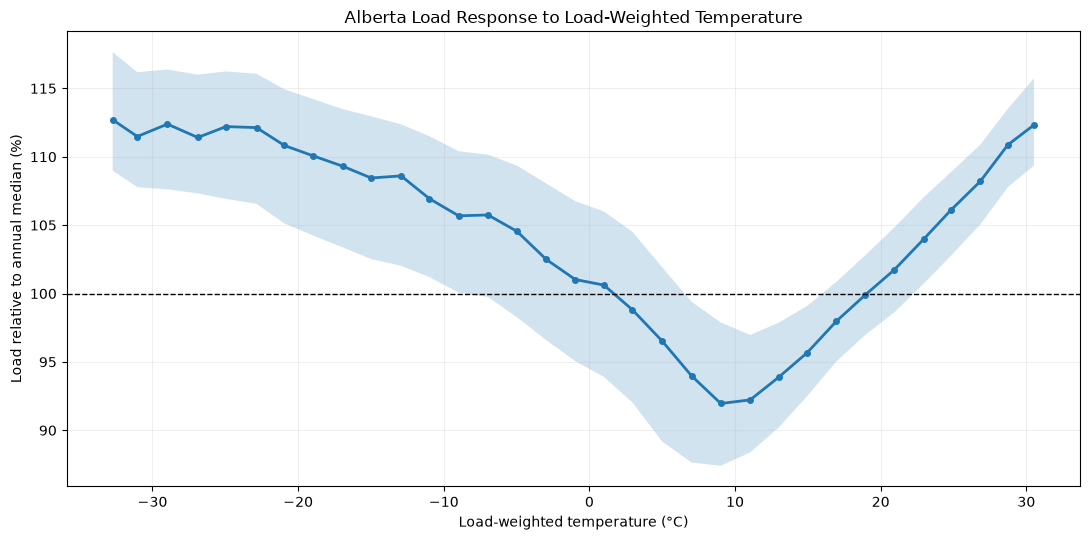

In [11]:
# ---------------------------------------------------------------------
# Plot the temperature-load response
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    temperature_response[
        "median_temperature_c"
    ],
    temperature_response[
        "median_load_index"
    ],
    linewidth=2,
    marker="o",
    markersize=4,
)

ax.fill_between(
    temperature_response[
        "median_temperature_c"
    ],
    temperature_response[
        "load_index_25th_percentile"
    ],
    temperature_response[
        "load_index_75th_percentile"
    ],
    alpha=0.20,
)

ax.axhline(
    100,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.set_title(
    "Alberta Load Response to "
    "Load-Weighted Temperature"
)
ax.set_xlabel("Load-weighted temperature (°C)")
ax.set_ylabel(
    "Load relative to annual median (%)"
)
ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

#### Temperature findings

Alberta load exhibits a clear U-shaped relationship with temperature. Demand is lowest near 9–11°C, at approximately 92% of the annual median, and rises as conditions become either colder or hotter. Load reaches roughly 112% during both extreme cold and extreme heat, consistent with heating and cooling demand.

The response is broader and more persistent on the cold side, while hot-weather demand increases sharply above approximately 20°C. Estimates at the most extreme temperatures are less precise because those conditions occur less frequently.

### 2.2 Annual stability

Absolute temperature bands are compared across years. Each cell reports median load relative to that year’s median load.

A stable physical response should show consistently elevated load during severe cold and, where sufficiently represented, extreme heat. Cells with fewer than 100 observations are suppressed.

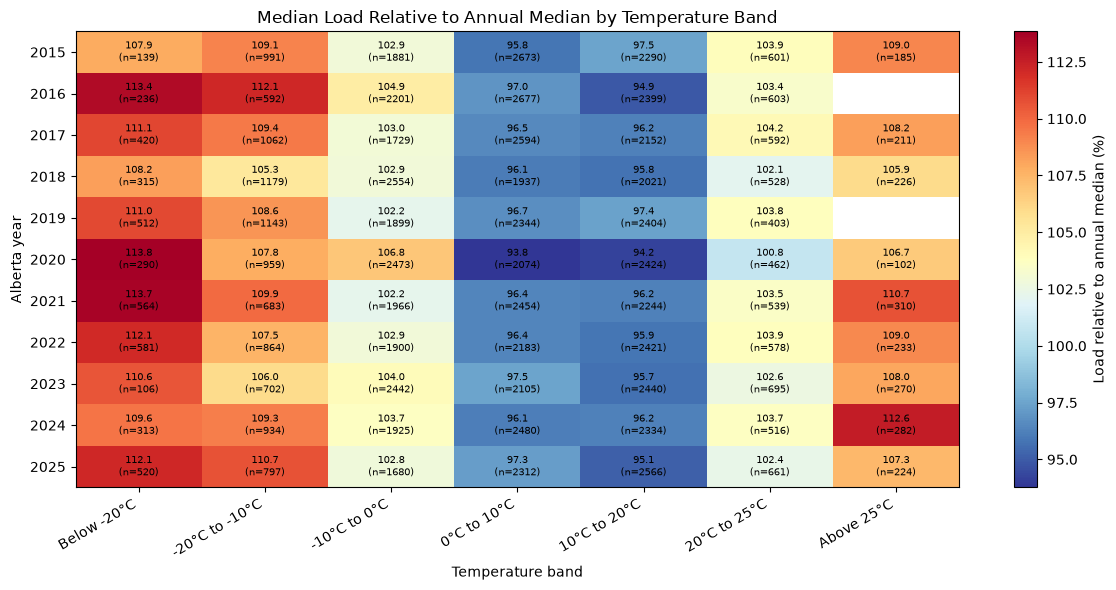

In [12]:
# ---------------------------------------------------------------------
# Test annual stability across absolute temperature bands
# ---------------------------------------------------------------------

TEMPERATURE_BAND_ORDER = [
    "Below -20°C",
    "-20°C to -10°C",
    "-10°C to 0°C",
    "0°C to 10°C",
    "10°C to 20°C",
    "20°C to 25°C",
    "Above 25°C",
]

temperature_band = pd.cut(
    master["load_weighted_temperature_c"],
    bins=[
        -np.inf,
        -20,
        -10,
        0,
        10,
        20,
        25,
        np.inf,
    ],
    labels=TEMPERATURE_BAND_ORDER,
    right=False,
)

annual_temperature_response = (
    pd.DataFrame({
        "year_alberta":
            master["year_alberta"],
        "temperature_band":
            temperature_band,
        "load_index":
            weather_features[
                "load_index_within_year"
            ],
    })
    .dropna()
    .groupby(
        [
            "year_alberta",
            "temperature_band",
        ],
        observed=True,
    )
    .agg(
        hours=("load_index", "size"),
        median_load_index=(
            "load_index",
            "median",
        ),
    )
    .reset_index()
)

annual_temperature_values = (
    annual_temperature_response
    .pivot(
        index="year_alberta",
        columns="temperature_band",
        values="median_load_index",
    )
    .reindex(columns=TEMPERATURE_BAND_ORDER)
)

annual_temperature_counts = (
    annual_temperature_response
    .pivot(
        index="year_alberta",
        columns="temperature_band",
        values="hours",
    )
    .reindex(
        index=annual_temperature_values.index,
        columns=TEMPERATURE_BAND_ORDER,
    )
)

displayed_temperature_values = (
    annual_temperature_values.where(
        annual_temperature_counts.ge(
            MINIMUM_BIN_HOURS
        )
    )
)

fig, ax = plt.subplots(figsize=(12, 6))

image = ax.imshow(
    displayed_temperature_values,
    aspect="auto",
    cmap="RdYlBu_r",
)

ax.set_xticks(
    range(len(TEMPERATURE_BAND_ORDER))
)
ax.set_xticklabels(
    TEMPERATURE_BAND_ORDER,
    rotation=30,
    ha="right",
)

ax.set_yticks(
    range(
        len(
            displayed_temperature_values.index
        )
    )
)
ax.set_yticklabels(
    displayed_temperature_values.index
)

for row in range(
    displayed_temperature_values.shape[0]
):
    for column in range(
        displayed_temperature_values.shape[1]
    ):
        value = displayed_temperature_values.iloc[
            row,
            column,
        ]

        count = annual_temperature_counts.iloc[
            row,
            column,
        ]

        if np.isfinite(value):
            ax.text(
                column,
                row,
                f"{value:.1f}\n"
                f"(n={count:.0f})",
                ha="center",
                va="center",
                fontsize=7,
            )

ax.set_title(
    "Median Load Relative to Annual Median "
    "by Temperature Band"
)
ax.set_xlabel("Temperature band")
ax.set_ylabel("Alberta year")

fig.colorbar(
    image,
    ax=ax,
    label="Load relative to annual median (%)",
)

plt.tight_layout()
plt.show()

#### Stability findings

The U-shaped temperature response is consistent across years. Load is generally highest below −20°C, reaching 108–114% of each year’s median, and lowest between 0°C and 20°C, at approximately 94–97%. Demand also rises above 25°C, although these hot-weather estimates are based on fewer observations and are therefore less stable.

This consistency indicates that temperature has a persistent relationship with Alberta demand despite changes in annual load levels and market structure.

### 2.3 Other weather variables

Temperature is likely to capture most of the direct weather relationship with load. Other variables may add descriptive information, but many are mechanically related to temperature.

The following screen first removes each temperature bin’s median load response, then measures whether humidity, spatial temperature dispersion, temperature changes, wind chill, or heat index remain associated with the residual.

This is a descriptive conditional screen, not a causal or predictive model.

In [13]:
# ---------------------------------------------------------------------
# Screen weather modifiers after removing binned temperature response
# ---------------------------------------------------------------------

modifier_frame = pd.DataFrame({
    "year_alberta": master["year_alberta"],
    "temperature_c": master["load_weighted_temperature_c"],
    "load_index": weather_features["load_index_within_year"],
    "humidity_pct": master["load_weighted_relative_humidity_pct"],
    "temperature_spatial_std_c": master["load_temperature_spatial_std_c"],
    "temperature_change_6h_c": master["load_temperature_change_6h_c"],
    "wind_chill_c": master["load_weighted_wind_chill_c"],
    "heat_index_c": master["load_weighted_heat_index_c"],
})

modifier_frame["temperature_bin_c"] = (
    np.floor(
        modifier_frame["temperature_c"] / TEMPERATURE_BIN_WIDTH_C
    ) * TEMPERATURE_BIN_WIDTH_C
)

modifier_frame["expected_load_index_in_bin"] = (
    modifier_frame.groupby(
        ["year_alberta", "temperature_bin_c"]
    )["load_index"].transform("median")
)

modifier_frame["temperature_adjusted_load_index"] = (
    modifier_frame["load_index"] - modifier_frame["expected_load_index_in_bin"]
)

modifier_definitions = {
    "Relative humidity": ("humidity_pct", modifier_frame["humidity_pct"].notna()),
    "Temperature spatial dispersion": ("temperature_spatial_std_c", modifier_frame["temperature_spatial_std_c"].notna()),
    "Six-hour temperature change": ("temperature_change_6h_c", modifier_frame["temperature_change_6h_c"].notna()),
    "Wind chill during cold conditions": ("wind_chill_c", modifier_frame["temperature_c"].le(0) & modifier_frame["wind_chill_c"].notna()),
    "Heat index when reported": ("heat_index_c", modifier_frame["heat_index_c"].notna()),
}

modifier_rows = []

for (label, (column, condition)) in modifier_definitions.items():
    sample = modifier_frame.loc[
        condition,
        [column, "temperature_adjusted_load_index"],
    ].dropna()

    modifier_rows.append({
        "weather_modifier": label,
        "observations": len(sample),
        "coverage_pct": len(sample) / len(master) * 100,
        "spearman_with_temperature_adjusted_load": sample[column].corr(sample["temperature_adjusted_load_index"], method="spearman",),
    })

weather_modifier_screen = pd.DataFrame(modifier_rows)

display(weather_modifier_screen.round(3))

,weather_modifier,observations,coverage_pct,spearman_with_temperature_adjusted_load
0,Relative humidity,96432,100.000,-0.232
1,Temperature spatial dispersion,96432,100.000,0.141
2,Six-hour temperature change,96432,100.000,0.433
3,Wind chill during cold conditions,36538,37.890,0.002
4,Heat index when reported,919,0.953,-0.027


#### Additional-weather findings

After accounting for temperature, six-hour temperature change has the strongest remaining association with load (ρ = 0.433), suggesting that recent weather transitions may contain additional demand information. Relative humidity has a modest negative relationship, while spatial temperature dispersion is weakly positive.

Wind chill and heat index show almost no additional monotonic relationship. The heat-index result is especially uncertain because it is reported for less than 1% of observations.

### 2.4 Temperature changes and load ramps

Rapid cooling and warming may matter differently depending on the prevailing temperature state.

This section compares six-hour load changes during rapid cooling, typical temperature movement, and rapid warming. It is a compact descriptive ramp analysis rather than an exhaustive lag-selection exercise.

In [14]:
# ---------------------------------------------------------------------
# Compare temperature changes with load ramps
# ---------------------------------------------------------------------

weather_features['load_change_6h_mw'] = (
    master['ail_mw'].diff(6)
)

temperature_change_percentile = (
    within_year_percentile(master["load_temperature_change_6h_c"])
)

TEMPERATURE_CHANGE_STATE_ORDER = [
    'Rapid cooling',
    'Typical change',
    'Rapid warming',
]

temperature_change_state = pd.Categorical(
    np.select(
        [temperature_change_percentile.le(0.05), temperature_change_percentile.ge(0.95)],
        ["Rapid cooling", "Rapid warming"],
        default = "Typical change",
    ),
    categories = TEMPERATURE_CHANGE_STATE_ORDER,
    ordered = True
)

temperature_ramp_summary = (
    pd.DataFrame({
        "temperature_band": temperature_band,
        "temperature_change_state": temperature_change_state,
        "temperature_change_6h_c": master["load_temperature_change_6h_c"],
        "load_change_6h_mw": weather_features["load_change_6h_mw"]
    })
    .dropna()
    .groupby(
        ["temperature_band", "temperature_change_state"],
        observed=True,
    )
    .agg(
        hours=("load_change_6h_mw", "size"),
        median_temperature_change_c=("temperature_change_6h_c", "median"),
        mean_load_change_mw=("load_change_6h_mw", "mean"),
        median_load_change_mw=("load_change_6h_mw", "median"),
    )
    .reset_index()
)

display(temperature_ramp_summary.round(2))

,temperature_band,temperature_change_state,hours,median_temperature_change_c,mean_load_change_mw,median_load_change_mw
0,Below -20°C,Rapid cooling,13,-7.88,-758.54,-812.0
1,Below -20°C,Typical change,3965,-1.26,-22.04,64.0
2,Below -20°C,Rapid warming,18,10.69,75.94,8.5
3,-20°C to -10°C,Rapid cooling,45,-8.46,-530.60,-614.0
4,-20°C to -10°C,Typical change,9765,-0.97,-2.25,65.0
5,-20°C to -10°C,Rapid warming,96,10.60,17.89,-74.0
6,-10°C to 0°C,Rapid cooling,181,-8.65,-530.54,-578.0
7,-10°C to 0°C,Typical change,22219,-1.02,-23.71,16.0
8,-10°C to 0°C,Rapid warming,244,10.53,-32.25,-90.5
9,0°C to 10°C,Rapid cooling,1473,-9.19,-758.00,-802.0


#### Ramp findings

Rapid temperature changes coincide with substantial load ramps, but their direction depends on the prevailing temperature. Above 10°C, rapid warming is associated with rising load—exceeding 1,100 MW in hot conditions—while rapid cooling accompanies large load declines. Similar declines during rapid cooling at colder temperatures suggest that time-of-day and weather-system timing also influence the result.

These relationships are descriptive rather than causal, and estimates for the coldest rapid-change conditions rely on relatively few observations.

#### Temperature summary

Alberta’s temperature–load relationship is strongly U-shaped. Load is lowest near 9–11°C and rises during both cold and hot conditions, reaching approximately 112% of the annual median at either extreme. Cold sensitivity is broader and more consistently observed, while hot-weather demand increases sharply above 20°C but is supported by fewer observations. This pattern persists across years after normalizing for annual load levels.

After conditioning on temperature, six-hour temperature change retains the strongest additional relationship with load. Humidity and spatial temperature dispersion add modest information, whereas wind chill and heat index contribute little independently. Rapid warming above 10°C coincides with substantial load increases, while rapid cooling accompanies large declines; however, these relationships may also reflect time-of-day and weather-system timing.

These results establish temperature level and recent temperature change as the principal historical weather indicators of demand. Forecasting applications must replace the realized hourly weather fields with information available from weather forecasts at the intended forecast origin.

## 3. Wind

Wind speed is linked to normalized generation before the analysis turns to regime stability, persistent low-wind events, ramps, and geographic smoothing.

### 3.1 Wind-speed response

Wind generation is normalized by reported wind system capacity to separate weather-driven output from long-term fleet growth.

The analysis compares capacity-weighted 100-metre wind speed with realized wind capacity factor. The resulting curve is an aggregate empirical relationship, not a turbine-level engineering power curve.

Differences between weather-implied output and realized generation may reflect outages, curtailment, transmission constraints, project coverage, wake effects, or measurement differences.

In [15]:
# ---------------------------------------------------------------------
# Build the empirical wind-speed response
# ---------------------------------------------------------------------

wind_frame = pd.DataFrame({
    "wind_speed_100m": master["wind_capacity_weighted_speed_100m"],
    "wind_capacity_factor_pct": weather_features["wind_capacity_factor_pct"],
    "wind_generation_mw": master["wind_system_generation"],
    "wind_capacity_mw": master["wind_system_capacity"],
    "wind_speed_spatial_std": master["wind_speed_100m_spatial_std"]
}).dropna()

wind_frame["wind_speed_bin_ms"] = (
    np.floor(wind_frame["wind_speed_100m"] / WIND_SPEED_BIN_WIDTH_MS)
    * WIND_SPEED_BIN_WIDTH_MS
)

wind_speed_response = (
    wind_frame
    .groupby("wind_speed_bin_ms")
    .agg(
        hours=("wind_capacity_factor_pct", "size"),
        median_wind_speed_ms=("wind_speed_100m", "median"),
        median_capacity_factor_pct=("wind_capacity_factor_pct", "median"),
        capacity_factor_25th_percentile=("wind_capacity_factor_pct", lambda series: series.quantile(0.25)),
        capacity_factor_75th_percentile=("wind_capacity_factor_pct", lambda series: series.quantile(0.75)),
    )
    .reset_index()
)

wind_speed_response = (
    wind_speed_response.loc[wind_speed_response["hours"].ge(MINIMUM_BIN_HOURS)]
)

display(wind_speed_response.round(2))

,wind_speed_bin_ms,hours,median_wind_speed_ms,median_capacity_factor_pct,capacity_factor_25th_percentile,capacity_factor_75th_percentile
1,1.0,2663,1.73,1.46,0.55,3.18
2,2.0,9301,2.58,4.01,2.00,7.22
3,3.0,13957,3.52,9.42,5.55,14.68
4,4.0,15390,4.49,17.81,12.00,24.84
5,5.0,14106,5.49,28.18,21.09,35.90
6,6.0,12026,6.47,39.42,32.04,47.54
7,7.0,9236,7.49,50.97,43.37,58.76
8,8.0,7506,8.46,60.81,52.62,68.60
9,9.0,5173,9.44,68.61,59.76,75.94
10,10.0,3390,10.43,73.37,64.56,80.48


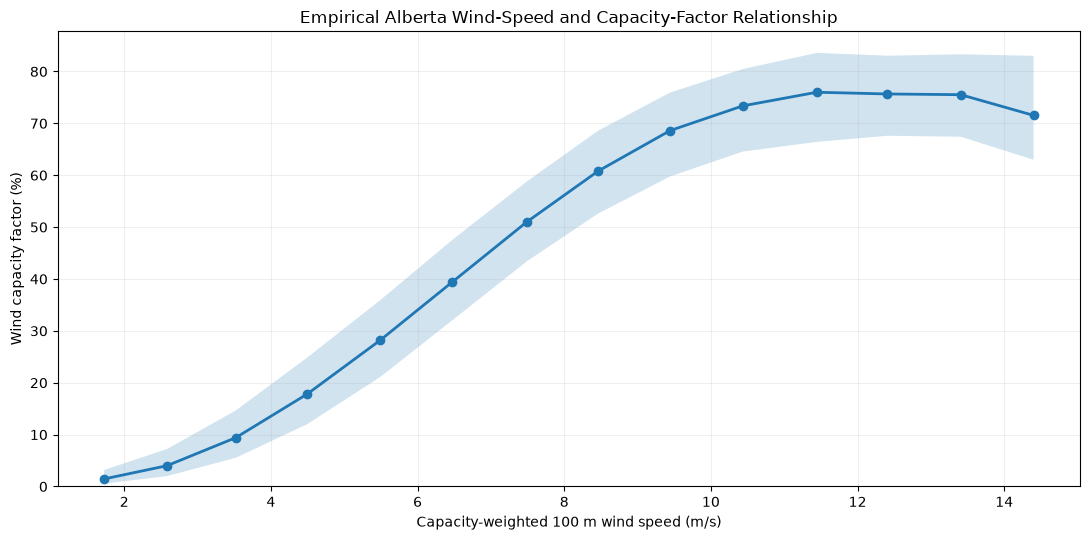

In [16]:
# ---------------------------------------------------------------------
# Plot the empirical wind-power relationship
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    wind_speed_response["median_wind_speed_ms"],
    wind_speed_response["median_capacity_factor_pct"],
    marker="o",
    linewidth=2,
)

ax.fill_between(
    wind_speed_response["median_wind_speed_ms"],
    wind_speed_response["capacity_factor_25th_percentile"],
    wind_speed_response["capacity_factor_75th_percentile"],
    alpha=0.20,
)

ax.set_title(
    "Empirical Alberta Wind-Speed "
    "and Capacity-Factor Relationship"
)
ax.set_xlabel(
    "Capacity-weighted 100 m wind speed (m/s)"
)
ax.set_ylabel("Wind capacity factor (%)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.20)

plt.tight_layout()
plt.show()

#### Wind-speed findings

Wind capacity factor follows the expected nonlinear power-curve relationship. Median output rises from approximately 4% at 2.6 m/s to 61% at 8.5 m/s, then plateaus near 75–76% between 11 and 13 m/s. The slight decline at the highest speeds may reflect curtailment, turbine protection, geographic aggregation, or limited observations.

This is a system-level empirical relationship rather than an individual turbine power curve, so variation also reflects outages, turbine characteristics, and differences between measured and site-level wind conditions.

### 3.2 Stability across regimes

The wind-speed relationship is repeated across structural market regimes using identical axes.

This tests whether the aggregate power-curve relationship changes as Alberta’s wind fleet expands geographically and technologically. The 2025 regime contains only one year and should be interpreted as preliminary.

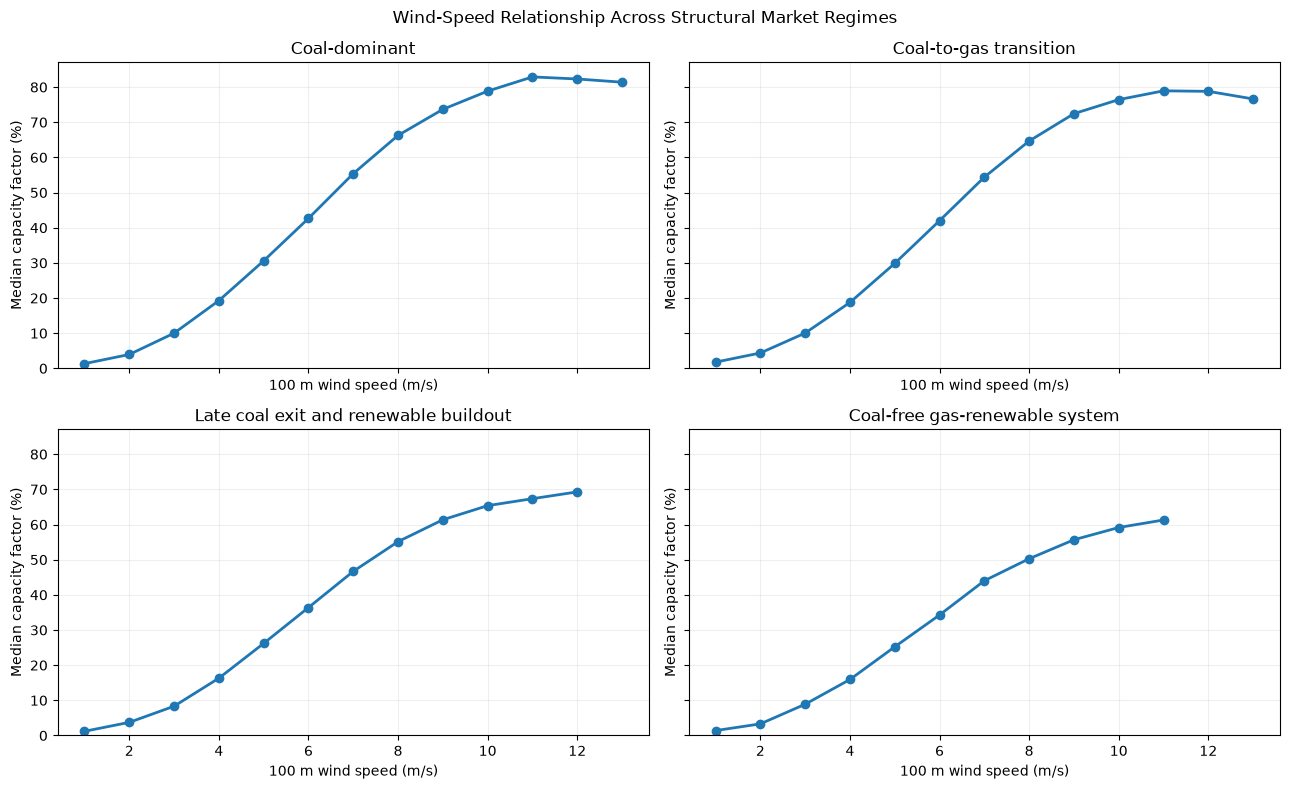

In [17]:
# ---------------------------------------------------------------------
# Compare wind-speed response across structural regimes
# ---------------------------------------------------------------------

wind_regime_response = (
    pd.DataFrame({
        "structural_regime": structural_regime,
        "wind_speed_bin_ms": np.floor(master["wind_capacity_weighted_speed_100m"] / WIND_SPEED_BIN_WIDTH_MS) * WIND_SPEED_BIN_WIDTH_MS,
        "wind_capacity_factor_pct": weather_features["wind_capacity_factor_pct"],
    })
    .dropna()
    .groupby(
        ["structural_regime", "wind_speed_bin_ms"],
        observed=True,
    )
    .agg(
        hours=("wind_capacity_factor_pct", "size"),
        median_capacity_factor_pct=("wind_capacity_factor_pct", "median"),
    )
    .reset_index()
)

maximum_wind_cf = (
    wind_regime_response["median_capacity_factor_pct"].max()
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8),
    sharex=True,
    sharey=True,
)

for axis, regime in zip(
    axes.flatten(),
    STRUCTURAL_REGIME_ORDER,
):
    plot_data = (
        wind_regime_response.loc[
            wind_regime_response["structural_regime"].eq(regime)
            & wind_regime_response["hours"].ge(MINIMUM_BIN_HOURS)
        ]
        .sort_values("wind_speed_bin_ms")
    )

    axis.plot(
        plot_data["wind_speed_bin_ms"],
        plot_data["median_capacity_factor_pct"],
        marker="o",
        linewidth=2,
    )

    axis.set_title(regime)
    axis.set_xlabel("100 m wind speed (m/s)")
    axis.set_ylabel("Median capacity factor (%)")
    axis.set_ylim(0, maximum_wind_cf * 1.05)
    axis.grid(alpha=0.20)

fig.suptitle(
    "Wind-Speed Relationship Across "
    "Structural Market Regimes"
)

plt.tight_layout()
plt.show()

#### Stability findings

The nonlinear wind-speed relationship persists across all structural regimes, confirming that wind speed remains a stable physical driver of generation. However, capacity factors at comparable wind speeds decline in later regimes: the high-speed plateau falls from roughly 80% in the earlier periods to about 69% during the renewable buildout and 61% in 2025.

This shift may reflect changes in fleet geography, turbine composition, curtailment, outages, capacity reporting, or the relationship between regional weather measurements and newer wind sites. Forecasting models should therefore allow the wind-speed conversion relationship to change over time rather than assuming one fixed historical power curve.

### 3.3 Low-wind episodes

Hours in the bottom 10% of each year’s capacity-weighted wind-speed distribution are grouped into consecutive low-wind episodes.

The episode analysis measures the frequency, duration, and realized wind output associated with persistent weak-wind conditions. It does not define an official wind-drought threshold.

In [18]:
# ---------------------------------------------------------------------
# Construct and summarize low-wind episodes
# ---------------------------------------------------------------------

wind_speed_percentile = (
    within_year_percentile(master["wind_capacity_weighted_speed_100m"])
)

low_wind_event = wind_speed_percentile.le(0.10)

low_wind_episode_id = build_episode_id(low_wind_event)

low_wind_hourly = pd.DataFrame({
    "episode_id": low_wind_episode_id,
    "timestamp_alberta": master["timestamp_alberta"],
    "wind_speed_100m": master["wind_capacity_weighted_speed_100m"],
    "wind_capacity_factor_pct": weather_features["wind_capacity_factor_pct"],
}).dropna(subset=["episode_id"])

low_wind_episodes = (
    low_wind_hourly
    .groupby("episode_id")
    .agg(
        start=("timestamp_alberta", "min"),
        end=("timestamp_alberta", "max"),
        duration_hours=("timestamp_alberta", "size"),
        minimum_wind_speed_ms=("wind_speed_100m", "min"),
        average_wind_speed_ms=("wind_speed_100m", "mean"),
        average_capacity_factor_pct=("wind_capacity_factor_pct", "mean"),
        minimum_capacity_factor_pct=("wind_capacity_factor_pct", "min"),
    )
    .sort_values("duration_hours", ascending=False)
)

low_wind_display = low_wind_episodes.head(20).copy()

numeric_columns = (
    low_wind_display
    .select_dtypes(include="number")
    .columns
)

low_wind_display[numeric_columns] = (
    low_wind_display[numeric_columns].round(2)
)

display(low_wind_display)

,start,end,duration_hours,minimum_wind_speed_ms,average_wind_speed_ms,average_capacity_factor_pct,minimum_capacity_factor_pct
episode_id,,,,,,,
1343.0,2023-05-10 08:00:00-06:00,2023-05-12 17:00:00-06:00,58,1.03,1.86,3.73,0.10
981.0,2021-01-27 20:00:00-07:00,2021-01-29 17:00:00-07:00,46,0.96,1.94,1.00,0.00
328.0,2017-01-23 04:00:00-07:00,2017-01-24 18:00:00-07:00,39,1.31,1.74,0.51,0.02
1332.0,2023-04-12 09:00:00-06:00,2023-04-13 20:00:00-06:00,36,1.55,2.08,3.42,0.14
1289.0,2022-11-08 14:00:00-07:00,2022-11-10 00:00:00-07:00,35,1.73,2.42,1.93,0.25
802.0,2019-11-28 20:00:00-07:00,2019-11-30 06:00:00-07:00,35,1.13,1.94,1.25,0.00
1588.0,2025-01-01 17:00:00-07:00,2025-01-02 21:00:00-07:00,29,2.27,2.60,1.15,0.31
1510.0,2024-07-08 10:00:00-06:00,2024-07-09 13:00:00-06:00,28,1.39,2.29,2.44,0.33
1322.0,2023-03-24 23:00:00-06:00,2023-03-26 02:00:00-06:00,28,1.95,2.43,4.43,1.05


,duration_hours
count,1725.00
mean,5.59
std,4.99
min,1.00
50%,4.00
75%,8.00
90%,11.00
95%,14.80
99%,23.00
max,58.00


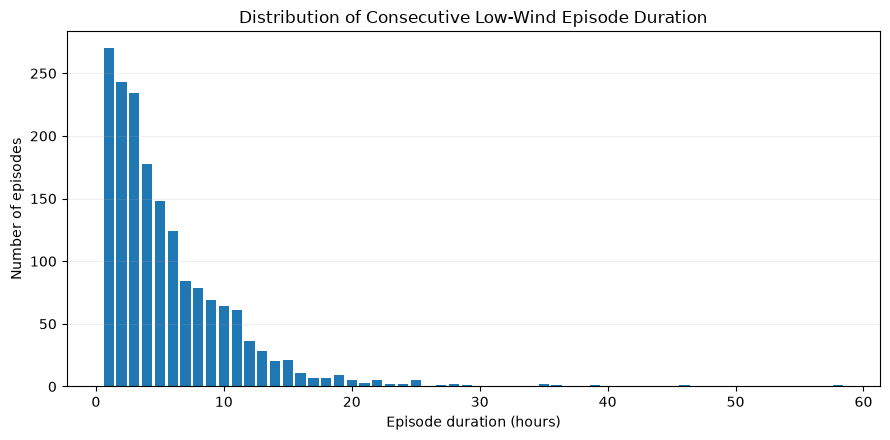

In [19]:
# ---------------------------------------------------------------------
# Summarize low-wind persistence
# ---------------------------------------------------------------------

low_wind_duration_summary = (
    low_wind_episodes["duration_hours"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame("duration_hours")
)

display(low_wind_duration_summary.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))

duration_counts = (
    low_wind_episodes["duration_hours"]
    .value_counts()
    .sort_index()
)

ax.bar(duration_counts.index, duration_counts.values)

ax.set_title(
    "Distribution of Consecutive "
    "Low-Wind Episode Duration"
)
ax.set_xlabel("Episode duration (hours)")
ax.set_ylabel("Number of episodes")
ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

#### Episode findings

The 1,725 identified low-wind episodes are strongly right-skewed. A typical event is brief—the median duration is four hours and 75% end within eight hours—but 5% persist for approximately 15 hours or longer, and 1% last at least 23 hours.

The longest episode continued for 58 hours, while several others lasted more than a full day. Average wind capacity factors during these extended events were generally below 5%, confirming that very low wind generation can occasionally persist across multiple operating periods.

### 3.4 Wind ramps and geographic dispersion

Wind-capacity-factor ramps are examined over one- and six-hour horizons. Ramps are normalized by capacity so fleet expansion does not mechanically increase their magnitude.

The analysis also tests whether geographically dispersed wind conditions are associated with smaller or larger aggregate ramps.

In [20]:
# ---------------------------------------------------------------------
# Summarize wind-capacity-factor ramps
# ---------------------------------------------------------------------

wind_ramp_rows = []

for horizon in [1, 3, 6, 12]:
    ramp = (weather_features["wind_capacity_factor_pct"].diff(horizon))

    wind_ramp_rows.append({
        "horizon_hours": horizon,
        "observations": ramp.notna().sum(),
        "mean_change_pct_points": ramp.mean(),
        "median_change_pct_points": ramp.median(),
        "mean_absolute_change_pct_points": ramp.abs().mean(),
        "90th_percentile_absolute_change": ramp.abs().quantile(0.90),
        "99th_percentile_absolute_change": ramp.abs().quantile(0.99),
    })

wind_ramp_summary = pd.DataFrame(wind_ramp_rows)

display(wind_ramp_summary.round(2))

,horizon_hours,observations,mean_change_pct_points,median_change_pct_points,mean_absolute_change_pct_points,90th_percentile_absolute_change,99th_percentile_absolute_change
0,1,96431,-0.0,-0.03,3.31,7.69,15.59
1,3,96429,-0.0,-0.09,7.82,18.02,34.44
2,6,96426,-0.0,-0.16,12.43,28.23,49.89
3,12,96420,-0.0,-0.07,17.59,39.15,63.51


In [21]:
# ---------------------------------------------------------------------
# Compare ramp magnitude across wind-dispersion states
# ---------------------------------------------------------------------

wind_dispersion_percentile = (
    within_year_percentile(master["wind_speed_100m_spatial_std"])
)

WIND_DISPERSION_STATE_ORDER = [
    "Low dispersion",
    "Typical dispersion",
    "High dispersion",
]

wind_dispersion_state = pd.Categorical(
    np.select(
        [wind_dispersion_percentile.le(0.20), wind_dispersion_percentile.ge(0.80)],
        ["Low dispersion", "High dispersion"],
        default="Typical dispersion",
    ),
    categories=WIND_DISPERSION_STATE_ORDER,
    ordered=True,
)

wind_dispersion_ramp_summary = (
    pd.DataFrame({
        "dispersion_state": wind_dispersion_state,
        "absolute_wind_cf_ramp_1h": weather_features["wind_capacity_factor_pct"].diff().abs(),
        "absolute_wind_cf_ramp_6h": weather_features["wind_capacity_factor_pct"].diff(6).abs(),
    })
    .dropna()
    .groupby(
        "dispersion_state",
        observed=True,
    )
    .agg(
        hours=("absolute_wind_cf_ramp_1h", "size"),
        median_absolute_ramp_1h=("absolute_wind_cf_ramp_1h", "median"),
        ramp_90th_percentile_1h=("absolute_wind_cf_ramp_1h", lambda series: series.quantile(0.90)),
        median_absolute_ramp_6h=("absolute_wind_cf_ramp_6h", "median"),
        ramp_90th_percentile_6h=("absolute_wind_cf_ramp_6h", lambda series: series.quantile(0.90)),
    )
)

display(wind_dispersion_ramp_summary.round(2))

,hours,median_absolute_ramp_1h,ramp_90th_percentile_1h,median_absolute_ramp_6h,ramp_90th_percentile_6h
dispersion_state,,,,,
Low dispersion,19283,1.55,6.85,7.06,26.65
Typical dispersion,57848,2.44,7.93,9.63,28.85
High dispersion,19295,2.49,7.74,9.65,27.76


#### Ramp findings

Wind capacity-factor changes are approximately balanced around zero, but their magnitude grows materially with the forecast horizon. The mean absolute change increases from 3.3 percentage points over one hour to 12.4 points over six hours and 17.6 points over twelve hours. At the six-hour horizon, the largest 10% of changes exceed 28 percentage points and the largest 1% approach 50 points.

Low spatial wind dispersion is associated with somewhat smaller typical ramps. However, typical- and high-dispersion conditions produce very similar ramp distributions, indicating that spatial dispersion alone provides limited separation of major wind-generation changes.

## 4. Solar

Daylight solar output is evaluated against irradiance, cloud and snow conditions, structural regimes, and short-horizon generation ramps.

### 4.1 Irradiance response

Solar analysis begins at the solar-generation reporting boundary and is restricted to daylight hours.

Solar generation is normalized by reported solar system capacity. The principal relationship compares capacity-weighted irradiance with realized solar capacity factor.

In [22]:
# ---------------------------------------------------------------------
# Build the daylight solar-response table
# ---------------------------------------------------------------------

solar_analysis_mask = (
    master["timestamp_alberta"].ge(solar_reporting_start)
) & weather_features["daylight"] & weather_features["solar_capacity_factor_pct"].notna()

solar_frame = pd.DataFrame({
    "structural_regime": structural_regime,
    "radiation_wm2": master["solar_capacity_weighted_radiation_wm2"],
    "solar_capacity_factor_pct": weather_features["solar_capacity_factor_pct"],
    "clear_sky_ratio": master["solar_clear_sky_radiation_ratio"],
    "cloud_cover": master["solar_capacity_weighted_total_cloud_cover"],
    "snow_depth": master["solar_capacity_weighted_snow_depth"],
}).loc[solar_analysis_mask].dropna(
    subset = ["radiation_wm2", "solar_capacity_factor_pct"]
)

solar_frame["radiation_bin_wm2"] = (
    np.floor(solar_frame["radiation_wm2"] / SOLAR_RADIATION_BIN_WIDTH_WM2) * SOLAR_RADIATION_BIN_WIDTH_WM2
)

solar_radiation_response = (
    solar_frame.groupby("radiation_bin_wm2").agg(
        hours = ("solar_capacity_factor_pct", "size"),
        median_radiation_wm2 = ("radiation_wm2", "median"),
        median_capacity_factor_pct = ("solar_capacity_factor_pct", "median"),
        capacity_factor_25th_percentile = ("solar_capacity_factor_pct", lambda series: series.quantile(0.25)),
        capacity_factor_75th_percentile = ("solar_capacity_factor_pct", lambda series: series.quantile(0.75)),
    ).reset_index()
)

solar_radiation_response = (
    solar_radiation_response.loc[solar_radiation_response["hours"].ge(MINIMUM_BIN_HOURS)]
)

display(solar_radiation_response.round(2))

,radiation_bin_wm2,hours,median_radiation_wm2,median_capacity_factor_pct,capacity_factor_25th_percentile,capacity_factor_75th_percentile
0,0.0,3225,25.18,0.82,0.00,10.04
1,50.0,3609,75.47,3.41,0.37,15.79
2,100.0,2773,123.79,7.46,2.02,20.72
3,150.0,2871,175.98,12.33,5.26,26.59
4,200.0,2907,225.68,18.67,9.00,34.47
5,250.0,2413,273.57,25.04,14.01,39.70
6,300.0,2035,324.82,31.52,18.87,47.43
7,350.0,2011,374.78,39.14,23.52,55.86
8,400.0,1838,424.11,45.65,28.13,63.12
9,450.0,1589,475.81,50.52,33.39,67.29


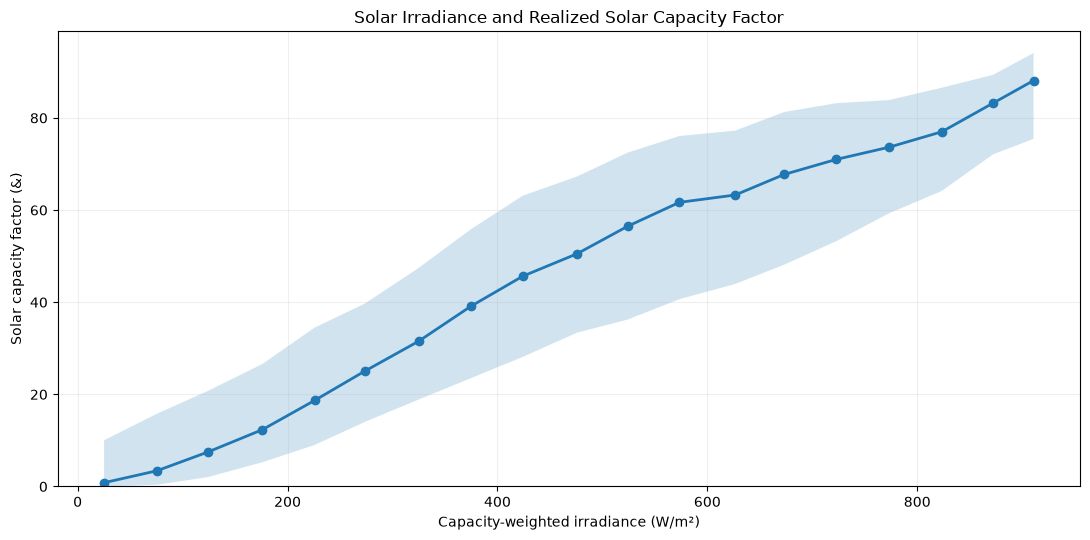

In [23]:
# ---------------------------------------------------------------------
# Plot the daylight solar-response curve
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize = (11, 5.5))

ax.plot(
    solar_radiation_response["median_radiation_wm2"],
    solar_radiation_response["median_capacity_factor_pct"],
    marker = "o",
    linewidth = 2,
)

ax.fill_between(
    solar_radiation_response["median_radiation_wm2"],
    solar_radiation_response["capacity_factor_25th_percentile"],
    solar_radiation_response["capacity_factor_75th_percentile"],
    alpha = 0.20,
)

ax.set_title(
    "Solar Irradiance and Realized "
    "Solar Capacity Factor"
)
ax.set_xlabel(
    "Capacity-weighted irradiance (W/m²)"
)
ax.set_ylabel("Solar capacity factor (&)")
ax.set_ylim(bottom = 0)
ax.grid(alpha = 0.20)

plt.tight_layout()
plt.show()

#### Irradiance findings

Solar capacity factor has a strong, nearly monotonic relationship with irradiance. Median capacity factor rises from less than 1% under minimal radiation to approximately 88% near 900 W/m², producing a considerably cleaner physical relationship than observed for wind generation.

The remaining variation within each radiation bin likely reflects cloud distribution, snow cover, temperature, curtailment, outages, and differences between the aggregated irradiance measure and conditions at individual solar facilities.

### 4.2 Stability across regimes

The irradiance relationship is repeated across market regimes to test whether fleet expansion changes its shape or level.

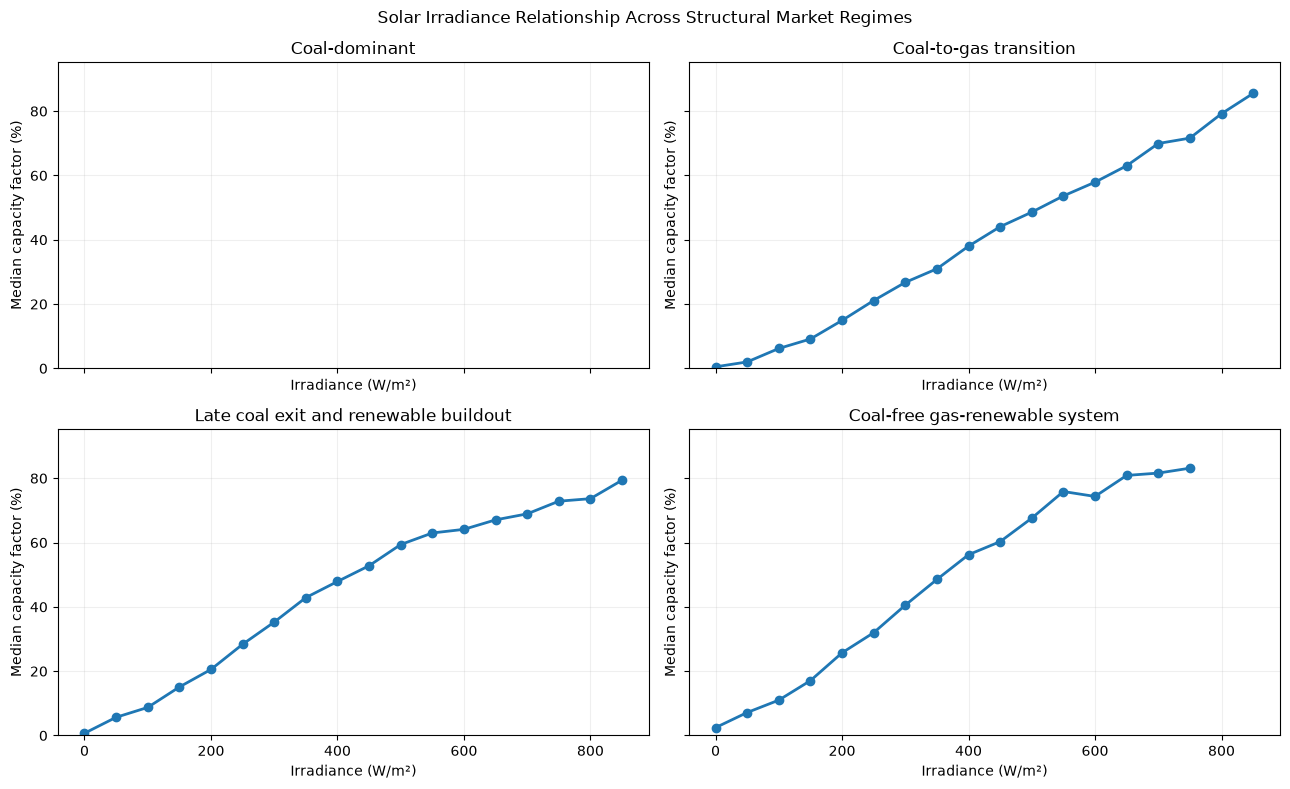

In [24]:
# ---------------------------------------------------------------------
# Compare solar response across structural regimes
# ---------------------------------------------------------------------

solar_regime_response = (
    solar_frame.groupby(["structural_regime", "radiation_bin_wm2"], observed=True)
    .agg(
        hours=("solar_capacity_factor_pct", "size"),
        median_capacity_factor_pct=("solar_capacity_factor_pct", "median"),
    ).reset_index()
)

maximum_solar_cf = (
    solar_regime_response["median_capacity_factor_pct"].max()
)

fig, axes = plt.subplots(
    2,
    2,
    figsize = (13, 8),
    sharex = True,
    sharey = True,
)

for axis, regime in zip(
    axes.flatten(),
    STRUCTURAL_REGIME_ORDER,
):
    plot_data = (
        solar_regime_response.loc[solar_regime_response["structural_regime"].eq(regime)
        & solar_regime_response["hours"].ge(MINIMUM_BIN_HOURS)]
        .sort_values("radiation_bin_wm2")
    )

    axis.plot(
        plot_data["radiation_bin_wm2"],
        plot_data["median_capacity_factor_pct"],
        marker="o",
        linewidth=2,
    )

    axis.set_title(regime)
    axis.set_xlabel("Irradiance (W/m²)")
    axis.set_ylabel("Median capacity factor (%)")
    axis.set_ylim(0, maximum_solar_cf * 1.05)
    axis.grid(alpha=0.20)

fig.suptitle(
    "Solar Irradiance Relationship Across "
    "Structural Market Regimes"
)

plt.tight_layout()
plt.show()


#### Stability findings

The positive irradiance–generation relationship remains clear across every regime with sufficient solar reporting. Its overall shape is stable, although the high-irradiance response varies modestly as the solar fleet expands and its composition changes.

The coal-dominant regime has insufficient observations because system-level solar reporting began near its end. The coal-free gas-renewable result currently represents only 2025 and should therefore be treated as preliminary. Overall, irradiance remains a consistent physical indicator of solar generation, but forecasting models may still benefit from periodic recalibration.

### 4.3 Cloud and snow

Cloud cover and snow may affect realized solar output at similar irradiance levels.

The following conditional summaries distinguish the main irradiance relationship from additional weather modifiers. These comparisons remain descriptive because plant-level snow cover, curtailment, outages, panel orientation, and maintenance are unavailable.

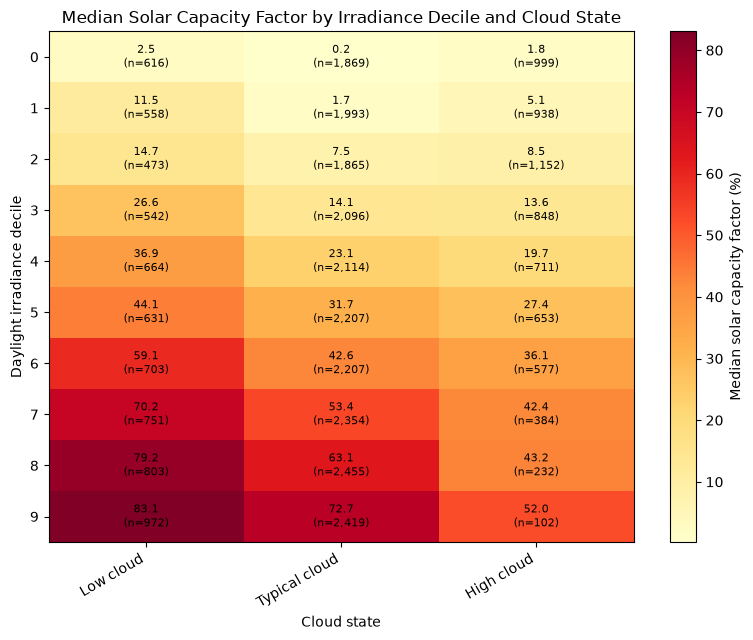

In [25]:
# ---------------------------------------------------------------------
# Define daylight irradiance and cloud states
# ---------------------------------------------------------------------

daylight_radiation_percentile = pd.Series(
    np.nan, index = master.index, dtype = float
)

daylight_radiation_percentile.loc[
    solar_analysis_mask
] = (
    pd.DataFrame({
        "year_alberta": master.loc[solar_analysis_mask, "year_alberta"],
        "radiation": master.loc[solar_analysis_mask, "solar_capacity_weighted_radiation_wm2"]
    }).groupby("year_alberta")["radiation"].rank(method = "average", pct = True)
)

weather_features["daylight_radiation_decile"] = percentile_to_decile(daylight_radiation_percentile)

cloud_percentile = (
    within_year_percentile(master["solar_capacity_weighted_total_cloud_cover"])
)

CLOUD_STATE_ORDER = [
    "Low cloud", 
    "Typical cloud", 
    "High cloud",
]

cloud_state = pd.Categorical(
    np.select([cloud_percentile.le(0.20), cloud_percentile.ge(0.80)], ["Low cloud", "High cloud"], default = "Typical cloud"),
    categories = CLOUD_STATE_ORDER, ordered = True,
)

solar_cloud_summary = (
    pd.DataFrame({
        "row_state": weather_features["daylight_radiation_decile"],
        "column_state": cloud_state,
        "solar_capacity_factor_pct": weather_features["solar_capacity_factor_pct"],
    }).loc[solar_analysis_mask].dropna().groupby(["row_state", "column_state"], observed = True).agg(
        hours = ("solar_capacity_factor_pct", "size"), 
        median_solar_capacity_factor = ("solar_capacity_factor_pct", "median")
    ).reset_index()
)

plot_state_heatmap(
    solar_cloud_summary,
    row_order = list(range(10)),
    column_order = CLOUD_STATE_ORDER,
    value_column = ("median_solar_capacity_factor"), 
    count_column = "hours", 
    title = (
        "Median Solar Capacity Factor by "
        "Irradiance Decile and Cloud State"
    ),
    row_label = "Daylight irradiance decile",
    column_label = "Cloud state",
    colorbar_label = ("Median solar capacity factor (%)")
)

In [26]:
# ---------------------------------------------------------------------
# Compare snow and non-snow conditions by irradiance decile
# ---------------------------------------------------------------------

snow_state = np.where(master["solar_capacity_weighted_snow_depth"].gt(0.001), "Snow reported", "No material snow")

solar_snow_summary = (
    pd.DataFrame({
        "radiation_decile": weather_features["daylight_radiation_decile"],
        "snow_state": snow_state,
        "solar_capacity_factor_pct": weather_features["solar_capacity_factor_pct"],
    }).loc[solar_analysis_mask].dropna().groupby(["radiation_decile", "snow_state"], observed=True).agg(
        hours=("solar_capacity_factor_pct", "size"),
        median_capacity_factor_pct=("solar_capacity_factor_pct", "median"),
    ).reset_index()
)

display(solar_snow_summary.round(2))

,radiation_decile,snow_state,hours,median_capacity_factor_pct
0,0,No material snow,1883,0.17
1,0,Snow reported,1601,2.96
2,1,No material snow,1821,2.06
3,1,Snow reported,1668,4.86
4,2,No material snow,1589,7.32
5,2,Snow reported,1901,8.95
6,3,No material snow,1655,14.77
7,3,Snow reported,1831,14.65
8,4,No material snow,1620,22.98
9,4,Snow reported,1869,24.88


#### Cloud and snow findings

Irradiance remains the dominant determinant of solar output, but cloud cover provides additional separation within comparable irradiance deciles. At the highest irradiance decile, median capacity factor falls from 83% under low cloud to 52% under high cloud, suggesting that the aggregated irradiance measure does not capture all site-level cloud variation.

Snow is associated with moderately lower output in the upper irradiance deciles, with reductions of roughly 4–7 percentage points. Its relationship is inconsistent under low irradiance, likely because snow occurrence is also related to season, daylight, temperature, and sample composition. These results are descriptive and do not independently identify curtailment or panel-level snow losses.

### 4.4 Solar ramps

One-, three-, and six-hour changes measure how quickly normalized solar output can rise or fall over operationally relevant horizons.

In [27]:
# ---------------------------------------------------------------------
# Summarize daylight solar-caapcity-factor ramps
# ---------------------------------------------------------------------

solar_ramp_rows = []

for horizon in [1, 3, 6]: 
    valid_transition = (solar_analysis_mask & solar_analysis_mask.shift(horizon, fill_value = False))

    ramp = (weather_features["solar_capacity_factor_pct"].diff(horizon).loc[valid_transition])

    solar_ramp_rows.append({
        "horizon_hours": horizon,
        "observations": ramp.notna().sum(),
        "mean_change_pct_points": ramp.mean(),
        "median_change_pct_points": ramp.median(),
        "mean_absolute_change_pct_points": ramp.abs().mean(),
        "90th_percentile_absolute_change": ramp.abs().quantile(0.90),
        "99th_percentile_absolute_change": ramp.abs().quantile(0.99),
    })

solar_ramp_summary = pd.DataFrame(solar_ramp_rows)

display(solar_ramp_summary.round(2))

,horizon_hours,observations,mean_change_pct_points,median_change_pct_points,mean_absolute_change_pct_points,90th_percentile_absolute_change,99th_percentile_absolute_change
0,1,31939,-1.63,-1.28,8.92,21.71,35.76
1,3,26041,-7.64,-5.89,22.56,52.53,72.22
2,6,17194,-16.00,-14.28,33.58,72.67,90.50


#### Ramp findings

Solar output changes rapidly over short horizons. The mean absolute capacity-factor change increases from 8.9 percentage points over one hour to 22.6 points over three hours and 33.6 points over six hours. At the six-hour horizon, 10% of changes exceed 72.7 points and 1% exceed 90 points.

The negative average changes indicate that the sample contains more pronounced downward ramps, likely reflecting afternoon and sunset transitions. Much of this movement follows the predictable daylight cycle rather than representing unexpected volatility; weather-driven forecast uncertainty should therefore be evaluated after controlling for hour, solar position, and clear-sky irradiance.

#### Solar summary

Irradiance has a strong, nearly monotonic relationship with realized solar capacity factor, which rises from near zero under minimal radiation to approximately 88% near 900 W/m². This relationship remains broadly stable as Alberta’s solar fleet expands, although the conversion at high irradiance varies modestly across regimes. The coal-dominant period has insufficient solar reporting, while the 2025 result remains preliminary.

Cloud cover adds substantial information within comparable irradiance deciles: at the highest decile, median capacity factor falls from 83% under low cloud to 52% under high cloud. Snow is associated with reductions of roughly 4–7 percentage points under stronger irradiance, but its low-irradiance relationship is confounded by season and daylight.

Daylight solar ramps are substantial. Mean absolute capacity-factor changes reach 8.9 points over one hour and 33.6 points over six hours, although much of this reflects predictable sunrise and sunset transitions. Irradiance, cloud cover, temperature, and snow depth all have forecast equivalents in numerical weather predictions, but deployment requires archived or live forecast vintages rather than realized weather. Solar capacity-factor analysis is restricted to the reporting period; pre-reporting generation is set to zero only when constructing historical net load.

## 5. Hydro

The available hydro fields are audited to separate observable generation and availability from unobserved reservoir and water-value constraints.

### 5.1 Coverage and limits

The canonical dataset contains hydro generation, availability, capacity, and outages. It does not contain reservoir levels, water values, inflows, runoff, snowmelt, or watershed-level precipitation.

Consequently, this notebook can describe hydro output and availability but cannot establish a defensible hourly weather-to-hydro relationship. Hourly precipitation should not be treated as an immediate hydro-generation input.

In [28]:
# ---------------------------------------------------------------------
# Summarize hydro generation and availability
# ---------------------------------------------------------------------

annual_hydro_summary = (
    pd.DataFrame({
        "year_alberta": master["year_alberta"],
        "hydro_generation_mw": master["hydro_system_generation"],
        "hydro_available_mw": master["hydro_system_available"],
        "hydro_capacity_mw": master["hydro_system_capacity"],
        "hydro_outage_mw": master["hydro_outage"],
        "hydro_capacity_factor_pct": weather_features["hydro_capacity_factor_pct"],
    }).groupby("year_alberta").agg(
        average_generation_mw = ("hydro_generation_mw", "mean"),
        average_available_mw = ("hydro_available_mw", "mean"),
        average_capacity_mw = ("hydro_capacity_mw", "mean"),
        average_outage_mw = ("hydro_outage_mw", "mean"),
        median_capacity_factor_pct = ("hydro_capacity_factor_pct", "median"),
        capacity_factor_90th_percentile = ("hydro_capacity_factor_pct", lambda series: series.quantile(0.90))
    )
)

display(annual_hydro_summary.round(2))

,average_generation_mw,average_available_mw,average_capacity_mw,average_outage_mw,median_capacity_factor_pct,capacity_factor_90th_percentile
year_alberta,,,,,,
2015,195.00,676.87,894.30,217.43,21.04,31.83
2016,197.29,733.78,894.30,160.52,21.78,32.50
2017,215.43,709.71,894.30,184.59,20.97,40.56
2018,212.47,719.75,894.30,174.55,21.12,40.07
2019,227.81,730.99,894.30,163.31,22.13,44.04
2020,231.70,699.40,894.30,194.90,22.01,46.27
2021,207.55,676.22,894.30,218.08,22.05,35.81
2022,219.48,719.51,894.30,174.79,21.35,40.73
2023,192.79,658.26,894.30,236.04,17.95,36.08


#### Hydro findings

Alberta’s hydro fleet remains relatively stable at approximately 894–898 MW of capacity. Average generation varies between 184 and 232 MW, while median capacity factor remains near 18–22%. Annual availability and outages fluctuate more noticeably, indicating that realized generation reflects operational availability and dispatch decisions rather than capacity growth.

The available inputs do not support a weather-attribution model. A complete hydro analysis would require: reservoir levels; inflow and runoff observations; watershed snowpack and precipitation; water-value or dispatch constraints; and operational release decisions.

Hydro weather modelling is therefore deferred rather than inferred from weak hourly proxies.

## 6. Compound weather and net load

Joint weather states show how demand and variable renewable output combine to produce extreme net-load conditions.

### 6.1 Weather states

Net load combines demand and variable renewable output:

Net load = Alberta Internal Load - wind generation - solar generation

The central question is which combinations of temperature and renewable availability create extreme net-load conditions.

Temperature states use absolute physical thresholds. Wind and solar states use within-year percentiles so renewable fleet expansion does not determine the classification.

In [29]:
# ---------------------------------------------------------------------
# Define interpretable weather and renewable-output states
# ---------------------------------------------------------------------

TEMPERATURE_STATE_ORDER = [
    "Extreme cold",
    "Cold",
    "Mild",
    "Hot",
    "Extreme hot",
]

temperature_state = pd.Categorical(
    pd.cut(master["load_weighted_temperature_c"],
        bins=[
            -np.inf,
            -20,
            0,
            20,
            25,
            np.inf,
        ],
        labels=TEMPERATURE_STATE_ORDER,
        right=False,
    ),
    categories=TEMPERATURE_STATE_ORDER,
    ordered=True,
)

WIND_STATE_ORDER = [
    "Low wind output",
    "Typical wind output",
    "High wind output",
]

wind_state = pd.Categorical(
    np.select(
        [weather_features["wind_cf_percentile_within_year"].le(0.20), weather_features["wind_cf_percentile_within_year"].ge(0.80)],
        ["Low wind output", "High wind output"],
        default="Typical wind output",
    ),
    categories=WIND_STATE_ORDER,
    ordered=True,
)

daylight_solar_percentile = pd.Series(
    np.nan,
    index=master.index,
    dtype=float,
)

daylight_solar_percentile.loc[
    solar_analysis_mask
] = (
    pd.DataFrame({
        "year_alberta": master.loc[solar_analysis_mask, "year_alberta"],
        "solar_capacity_factor_pct": weather_features.loc[solar_analysis_mask, "solar_capacity_factor_pct"],
    })
    .groupby("year_alberta")["solar_capacity_factor_pct"].rank(method="average", pct=True)
)

SOLAR_STATE_ORDER = [
    "Low solar output",
    "Typical solar output",
    "High solar output",
]

solar_state = pd.Series(
    pd.NA,
    index=master.index,
    dtype="string",
)

solar_state.loc[
    solar_analysis_mask
    & daylight_solar_percentile.le(0.20)
] = "Low solar output"

solar_state.loc[
    solar_analysis_mask
    & daylight_solar_percentile.between(0.20, 0.80, inclusive="neither")
] = "Typical solar output"

solar_state.loc[
    solar_analysis_mask
    & daylight_solar_percentile.ge(0.80)
] = "High solar output"

solar_state = pd.Categorical(
    solar_state,
    categories=SOLAR_STATE_ORDER,
    ordered=True,
)

### 6.2 Temperature and wind

Temperature and wind states are crossed to test whether severe cold becomes more consequential when wind output is also weak.

,row_state,column_state,hours,extreme_net_load_rate,average_load_mw,average_net_load_mw,average_wind_capacity_factor_pct,extreme_net_load_rate_pct
0,Extreme cold,Low wind output,1820,0.27,10816.59,10703.76,3.35,26.54
1,Extreme cold,Typical wind output,2108,0.07,10831.59,10159.68,23.56,6.55
2,Extreme cold,High wind output,68,0.00,10923.22,9098.01,60.87,0.00
3,Cold,Low wind output,5825,0.05,10096.13,9932.50,4.27,4.67
4,Cold,Typical wind output,18833,0.00,10083.25,9241.74,32.10,0.35
5,Cold,High wind output,7898,0.00,10108.13,8491.55,69.48,0.00
6,Mild,Low wind output,8790,0.00,9214.42,8914.67,4.62,0.00
7,Mild,Typical wind output,31829,0.00,9175.34,8298.95,30.63,0.00
8,Mild,High wind output,10909,0.00,9516.75,7725.50,69.11,0.00
9,Hot,Low wind output,2011,0.00,9991.54,9499.72,4.38,0.00


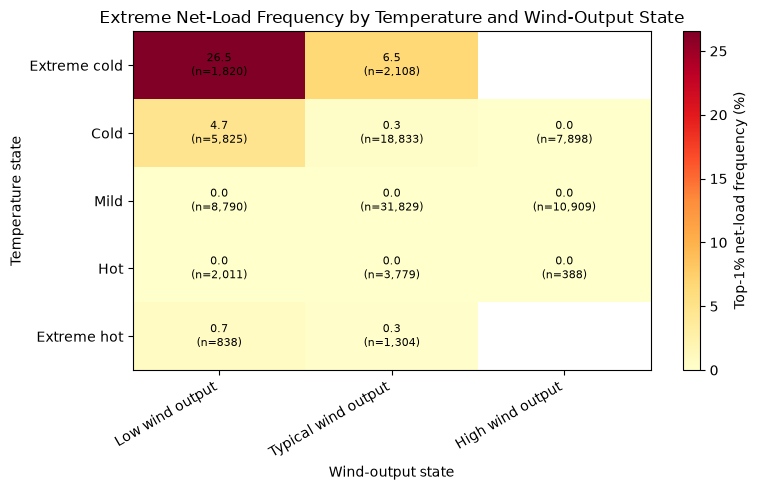

In [30]:
# ---------------------------------------------------------------------
# Summarize extreme net load across temperature and wind states
# ---------------------------------------------------------------------

temperature_wind_summary = (
    pd.DataFrame({
        "row_state": temperature_state,
        "column_state": wind_state,
        "extreme_net_load": weather_features["extreme_net_load_event"],
        "load_mw": master["ail_mw"],
        "net_load_mw": weather_features["net_load_mw"],
        "wind_capacity_factor_pct": weather_features[ "wind_capacity_factor_pct"],
    })
    .dropna()
    .groupby(
        ["row_state", "column_state"],
        observed=True,
    )
    .agg(
        hours=("extreme_net_load", "size"),
        extreme_net_load_rate=("extreme_net_load", "mean"),
        average_load_mw=("load_mw", "mean"),
        average_net_load_mw=("net_load_mw", "mean"),
        average_wind_capacity_factor_pct=("wind_capacity_factor_pct", "mean"),
    )
    .reset_index()
)

temperature_wind_summary[
    "extreme_net_load_rate_pct"
] = (
    temperature_wind_summary[
        "extreme_net_load_rate"
    ]
    * 100
)

display(temperature_wind_summary.round(2))

plot_state_heatmap(
    temperature_wind_summary,
    row_order=TEMPERATURE_STATE_ORDER,
    column_order=WIND_STATE_ORDER,
    value_column=("extreme_net_load_rate_pct"),
    count_column="hours",
    title=(
        "Extreme Net-Load Frequency by "
        "Temperature and Wind-Output State"
    ),
    row_label="Temperature state",
    column_label="Wind-output state",
    colorbar_label=("Top-1% net-load frequency (%)"),
)

#### Temperature-wind findings

Extreme net load is concentrated in hours when severe cold coincides with low wind output. Under extreme cold, the top-1% net-load rate reaches 26.5% during low-wind conditions, compared with 6.5% under typical wind output and effectively zero under high wind output. A similar but weaker pattern appears during less severe cold.

Extreme heat raises load, but rarely produces top-1% net load in this sample. The results therefore identify cold-driven demand combined with weak wind generation as Alberta’s clearest weather-related net-load risk. High-wind observations during the most extreme temperature states are limited, so those cells should be interpreted cautiously.

### 6.3 Wind and solar

Daylight wind and solar states are combined to identify hours when both variable renewable sources provide limited output.

,row_state,column_state,hours,extreme_net_load_rate,average_net_load_mw,average_variable_renewable_generation_mw,extreme_net_load_rate_pct
0,Low wind output,Low solar output,1426,0.15,10224.26,163.68,15.50
1,Low wind output,Typical solar output,4522,0.02,9593.14,434.59,2.39
2,Low wind output,High solar output,2566,0.00,9278.75,775.70,0.12
3,Typical wind output,Low solar output,4195,0.01,9282.88,885.16,0.93
4,Typical wind output,Typical solar output,12563,0.00,8859.40,1161.82,0.14
5,Typical wind output,High solar output,3927,0.00,8668.57,1326.10,0.08
6,High wind output,Low solar output,1314,0.00,8422.06,1914.65,0.00
7,High wind output,Typical solar output,3885,0.00,8152.30,2039.14,0.00
8,High wind output,High solar output,490,0.00,8064.33,1776.46,0.00


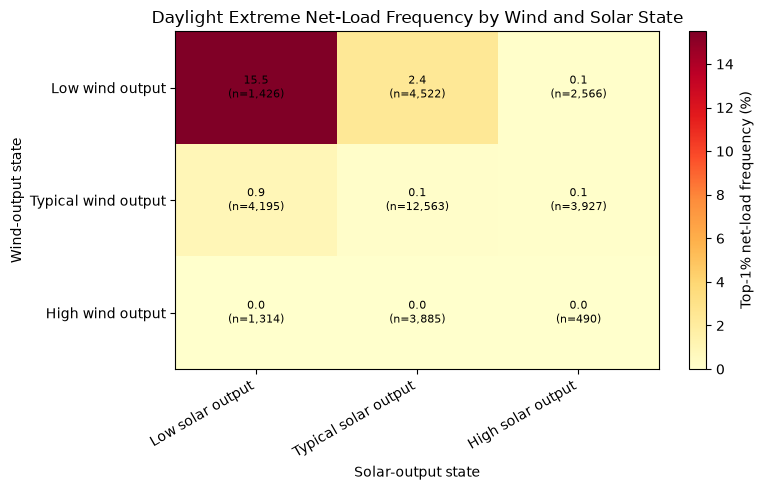

In [31]:
# ---------------------------------------------------------------------
# Summarize daylight net-load conditions by wind and solar state
# ---------------------------------------------------------------------

daylight_renewable_summary = (
    pd.DataFrame({
        "row_state": wind_state,
        "column_state": solar_state,
        "extreme_net_load": weather_features["extreme_net_load_event"],
        "net_load_mw": weather_features["net_load_mw"],
        "variable_renewable_generation_mw": weather_features["variable_renewable_generation_mw"],
    })
    .loc[solar_analysis_mask]
    .dropna()
    .groupby(
        ["row_state", "column_state"],
        observed=True,
    )
    .agg(
        hours=("extreme_net_load", "size"),
        extreme_net_load_rate=("extreme_net_load", "mean"),
        average_net_load_mw=("net_load_mw", "mean"),
        average_variable_renewable_generation_mw=("variable_renewable_generation_mw", "mean"),
    )
    .reset_index()
)

daylight_renewable_summary[
    "extreme_net_load_rate_pct"
] = (
    daylight_renewable_summary["extreme_net_load_rate"] * 100
)

display(daylight_renewable_summary.round(2))

plot_state_heatmap(
    daylight_renewable_summary,
    row_order=WIND_STATE_ORDER,
    column_order=SOLAR_STATE_ORDER,
    value_column=("extreme_net_load_rate_pct"),
    count_column="hours",
    title=(
        "Daylight Extreme Net-Load Frequency "
        "by Wind and Solar State"
    ),
    row_label="Wind-output state",
    column_label="Solar-output state",
    colorbar_label=("Top-1% net-load frequency (%)"),
)

#### Wind-solar findings

During daylight hours, extreme net load is concentrated when both wind and solar output are low. The top-1% net-load rate reaches 15.5% in the joint low-output state, compared with 2.4% when low wind coincides with typical solar and 0.1% when solar output is high.

Typical or high wind output largely prevents extreme net load regardless of solar state. This demonstrates the diversification value of renewable generation: strong output from either resource can materially reduce net load, while simultaneous weakness creates the greatest daytime system pressure.

### 6.4 Extreme net load

Top-1% net-load hours are compared with all other hours.

The comparison identifies whether extreme net load is primarily associated with:

- unusually high demand;
- unusually low wind output;
- limited daylight solar output;
- extreme cold or heat; or
- compound demand and renewable conditions.

These are contemporaneous operating comparisons, not causal contributions.

In [32]:
# ---------------------------------------------------------------------
# Compare extreme and non-extreme net-load conditions
# ---------------------------------------------------------------------

extreme_net_load = weather_features["extreme_net_load_event"]

net_load_condition_frame = pd.DataFrame({
    "load_mw": master["ail_mw"],
    "net_load_mw": weather_features["net_load_mw"],
    "temperature_c": master["load_weighted_temperature_c"],
    "wind_speed_100m": master["wind_capacity_weighted_speed_100m"],
    "wind_capacity_factor_pct": weather_features["wind_capacity_factor_pct"],
    "solar_generation_mw": solar_generation_filled,
    "variable_renewable_generation_mw": weather_features["variable_renewable_generation_mw"],
})

extreme_net_load_comparison = pd.DataFrame({
    "other_hours_mean": net_load_condition_frame.loc[~extreme_net_load].mean(),
    "extreme_hours_mean": net_load_condition_frame.loc[extreme_net_load].mean(),
    "other_hours_median": net_load_condition_frame.loc[~extreme_net_load].median(),
    "extreme_hours_median": net_load_condition_frame.loc[extreme_net_load].median(),
})

extreme_net_load_comparison["mean_difference"] = (
    extreme_net_load_comparison["extreme_hours_mean"]
    - extreme_net_load_comparison["other_hours_mean"]
)

display(extreme_net_load_comparison.round(2))


,other_hours_mean,extreme_hours_mean,other_hours_median,extreme_hours_median,mean_difference
load_mw,9658.64,11345.68,9661.00,11295.00,1687.04
net_load_mw,8731.83,11188.33,8755.97,11198.05,2456.50
temperature_c,3.91,-21.77,4.49,-22.83,-25.67
wind_speed_100m,5.87,3.29,5.51,3.16,-2.58
wind_capacity_factor_pct,33.23,5.42,29.15,3.48,-27.80
solar_generation_mw,108.98,24.05,0.00,0.00,-84.93
variable_renewable_generation_mw,926.81,157.35,722.99,101.94,-769.46


#### Extreme-net-load findings

Extreme net-load hours combine elevated demand with unusually weak renewable generation. Average load is approximately 1,687 MW higher than during other hours, while variable renewable generation is 769 MW lower, producing a net-load difference of roughly 2,457 MW.

These hours are predominantly very cold, with an average temperature near −22°C, and have substantially weaker wind conditions. Average wind capacity factor falls from 33% to 5%, while solar generation is also limited. Extreme net load therefore reflects a compound weather state: cold-driven demand occurring alongside low renewable output.

### 6.5 Stability across regimes

Compound-weather results are repeated across structural regimes to test whether the same high-net-load combinations persist as Alberta’s fleet evolves.

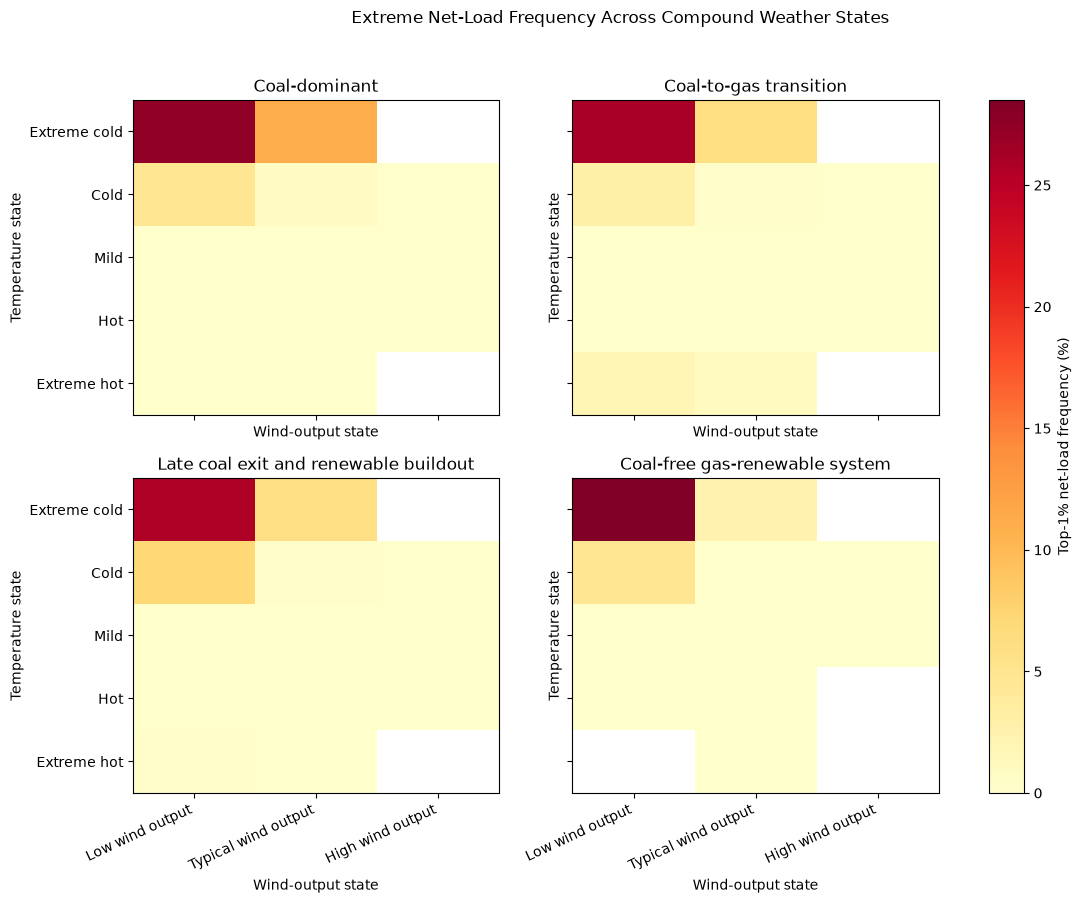

In [33]:
regime_compound_summary = (
    pd.DataFrame({
        "structural_regime": structural_regime,
        "temperature_state": temperature_state,
        "wind_state": wind_state,
        "extreme_net_load": weather_features["extreme_net_load_event"],
    })
    .dropna()
    .groupby(["structural_regime", "temperature_state", "wind_state"], observed=True)
    .agg(hours=("extreme_net_load", "size"), extreme_net_load_rate=("extreme_net_load", "mean"))
    .reset_index()
)

maximum_compound_rate = regime_compound_summary["extreme_net_load_rate"].max() * 100

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for axis, regime in zip(axes.flatten(), STRUCTURAL_REGIME_ORDER):
    data = regime_compound_summary[regime_compound_summary["structural_regime"].eq(regime)]

    values = (
        data.pivot(index="temperature_state", columns="wind_state", values="extreme_net_load_rate")
        .reindex(index=TEMPERATURE_STATE_ORDER, columns=WIND_STATE_ORDER) * 100
    )
    counts = (
        data.pivot(index="temperature_state", columns="wind_state", values="hours")
        .reindex(index=TEMPERATURE_STATE_ORDER, columns=WIND_STATE_ORDER)
    )

    image = axis.imshow(
        values.where(counts.ge(MINIMUM_STATE_HOURS)),
        aspect="auto", cmap="YlOrRd", vmin=0, vmax=maximum_compound_rate,
    )
    axis.set(
        title=regime,
        xticks=range(len(WIND_STATE_ORDER)),
        xticklabels=WIND_STATE_ORDER,
        yticks=range(len(TEMPERATURE_STATE_ORDER)),
        yticklabels=TEMPERATURE_STATE_ORDER,
        xlabel="Wind-output state",
        ylabel="Temperature state",
    )
    plt.setp(axis.get_xticklabels(), rotation=25, ha="right")

fig.suptitle("Extreme Net-Load Frequency Across Compound Weather States")
fig.colorbar(image, ax=axes.ravel().tolist(), label="Top-1% net-load frequency (%)")
plt.show()


#### Stability findings

The compound relationship between extreme cold, low wind, and extreme net load persists across every structural regime. In each period, extreme cold combined with low wind produces the highest event frequency, while typical or high wind output substantially reduces the risk.

The consistency of this pattern indicates that the cold–low-wind combination is a persistent physical system risk rather than a feature of one market period. White cells represent combinations with insufficient observations, and the coal-free gas-renewable regime remains preliminary because it currently contains only 2025.

### 6.6 Extreme-net-load events

Consecutive top-1% net-load hours are grouped into episodes. Each episode is aligned at onset to examine how temperature, load, wind, solar, and net load evolve before and after the event begins.

These are net-load episodes rather than price-scarcity episodes. Notebook 2 remains responsible for determining how net-load conditions translate into scarcity.

In [34]:
# ---------------------------------------------------------------------
# Construct extreme net-load episodes
# ---------------------------------------------------------------------

extreme_net_load_episode_id = build_episode_id(weather_features["extreme_net_load_event"])

extreme_net_load_hourly = pd.DataFrame({
    "episode_id": extreme_net_load_episode_id,
    "timestamp_alberta": master["timestamp_alberta"],
    "load_mw": master["ail_mw"],
    "net_load_mw": weather_features["net_load_mw"],
    "temperature_c": master["load_weighted_temperature_c"],
    "wind_capacity_factor_pct": weather_features["wind_capacity_factor_pct"],
    "solar_generation_mw": solar_generation_filled,
}).dropna(subset=["episode_id"])

extreme_net_load_episodes = (
    extreme_net_load_hourly.groupby("episode_id")
    .agg(
        start=("timestamp_alberta", "min"),
        end=("timestamp_alberta", "max"),
        duration_hours=("timestamp_alberta", "size"),
        peak_load_mw=("load_mw", "max"),
        peak_net_load_mw=("net_load_mw", "max"),
        minimum_temperature_c=("temperature_c", "min"),
        maximum_temperature_c=("temperature_c", "max"),
        average_wind_capacity_factor_pct=("wind_capacity_factor_pct", "mean"),
        average_solar_generation_mw=("solar_generation_mw", "mean"),
    )
    .sort_values(["duration_hours", "peak_net_load_mw"], ascending=False)
)

extreme_net_load_episode_preview = (
    extreme_net_load_episodes
    .head(20)
    .copy()
)

numeric_columns = (
    extreme_net_load_episode_preview
    .select_dtypes(include="number")
    .columns
)

extreme_net_load_episode_preview[numeric_columns] = (
    extreme_net_load_episode_preview[numeric_columns]
    .round(2)
)

display(extreme_net_load_episode_preview)

,start,end,duration_hours,peak_load_mw,peak_net_load_mw,minimum_temperature_c,maximum_temperature_c,average_wind_capacity_factor_pct,average_solar_generation_mw
episode_id,,,,,,,,,
188.0,2023-02-23 06:00:00-07:00,2023-02-23 23:00:00-07:00,18,11494,11461.74,-30.40,-23.01,1.06,178.27
230.0,2025-12-12 06:00:00-07:00,2025-12-12 22:00:00-07:00,17,12613,12074.22,-26.69,-21.68,7.36,83.24
173.0,2022-12-20 07:00:00-07:00,2022-12-20 21:00:00-07:00,15,12101,12025.80,-34.35,-30.69,2.23,41.90
69.0,2018-01-11 07:00:00-07:00,2018-01-11 21:00:00-07:00,15,11697,11563.65,-31.93,-24.74,4.38,0.16
36.0,2016-12-08 07:00:00-07:00,2016-12-08 21:00:00-07:00,15,11442,11442.00,-25.05,-21.39,0.02,0.00
118.0,2020-01-14 07:00:00-07:00,2020-01-14 20:00:00-07:00,14,11698,11563.16,-32.98,-29.24,5.16,0.07
65.0,2017-12-29 08:00:00-07:00,2017-12-29 21:00:00-07:00,14,11365,11339.17,-30.75,-27.02,1.55,0.00
45.0,2016-12-16 07:00:00-07:00,2016-12-16 20:00:00-07:00,14,11458,11234.32,-27.97,-21.42,9.78,0.00
4.0,2015-01-06 08:00:00-07:00,2015-01-06 21:00:00-07:00,14,11130,11130.00,-20.49,-17.58,1.03,0.00


In [35]:
# ---------------------------------------------------------------------
# Align weather and system conditions around net-load onset
# ---------------------------------------------------------------------

EVENT_WINDOW_START, EVENT_WINDOW_END = -24, 12

extreme_net_load_event = weather_features["extreme_net_load_event"]

extreme_net_load_onset = (
    extreme_net_load_event
    & ~extreme_net_load_event.shift(fill_value=False)
)

onset_positions = np.flatnonzero(extreme_net_load_onset.to_numpy())

aligned_variables = {
    "Load": master["ail_mw"],
    "Net load": weather_features["net_load_mw"],
    "Temperature": master["load_weighted_temperature_c"],
    "Wind capacity factor": weather_features["wind_capacity_factor_pct"],
    "Solar generation": solar_generation_filled,
    "Variable renewable generation": weather_features["variable_renewable_generation_mw"],
}

aligned_rows = []

for episode_number, onset_position in enumerate(onset_positions, start=1):
    start_position = onset_position + EVENT_WINDOW_START
    end_position = onset_position + EVENT_WINDOW_END

    if start_position < 0 or end_position >= len(master):
        continue

    aligned_block = pd.DataFrame({
        variable_name: values.iloc[start_position:end_position + 1].to_numpy()
        for variable_name, values in aligned_variables.items()
    })

    aligned_block["episode_number"] = episode_number
    aligned_block["relative_hour"] = np.arange(
        EVENT_WINDOW_START, EVENT_WINDOW_END + 1
    )

    aligned_rows.append(aligned_block)

event_aligned = pd.concat(aligned_rows, ignore_index=True)

event_aligned_long = event_aligned.melt(
    id_vars=["episode_number", "relative_hour"],
    var_name="variable",
    value_name="value",
)

event_aligned_profile = (
    event_aligned_long
    .groupby(["variable", "relative_hour"])["value"]
    .agg(
        median="median",
        q25=lambda series: series.quantile(0.25),
        q75=lambda series: series.quantile(0.75),
        observations="count",
    )
    .reset_index()
)

display(event_aligned_profile.head())


,variable,relative_hour,median,q25,q75,observations
0,Load,-24,11157.0,10882.0,11377.5,235
1,Load,-23,11237.0,10915.0,11428.5,235
2,Load,-22,11179.0,10858.0,11387.5,235
3,Load,-21,11090.0,10763.0,11348.0,235
4,Load,-20,11000.0,10601.0,11272.0,235


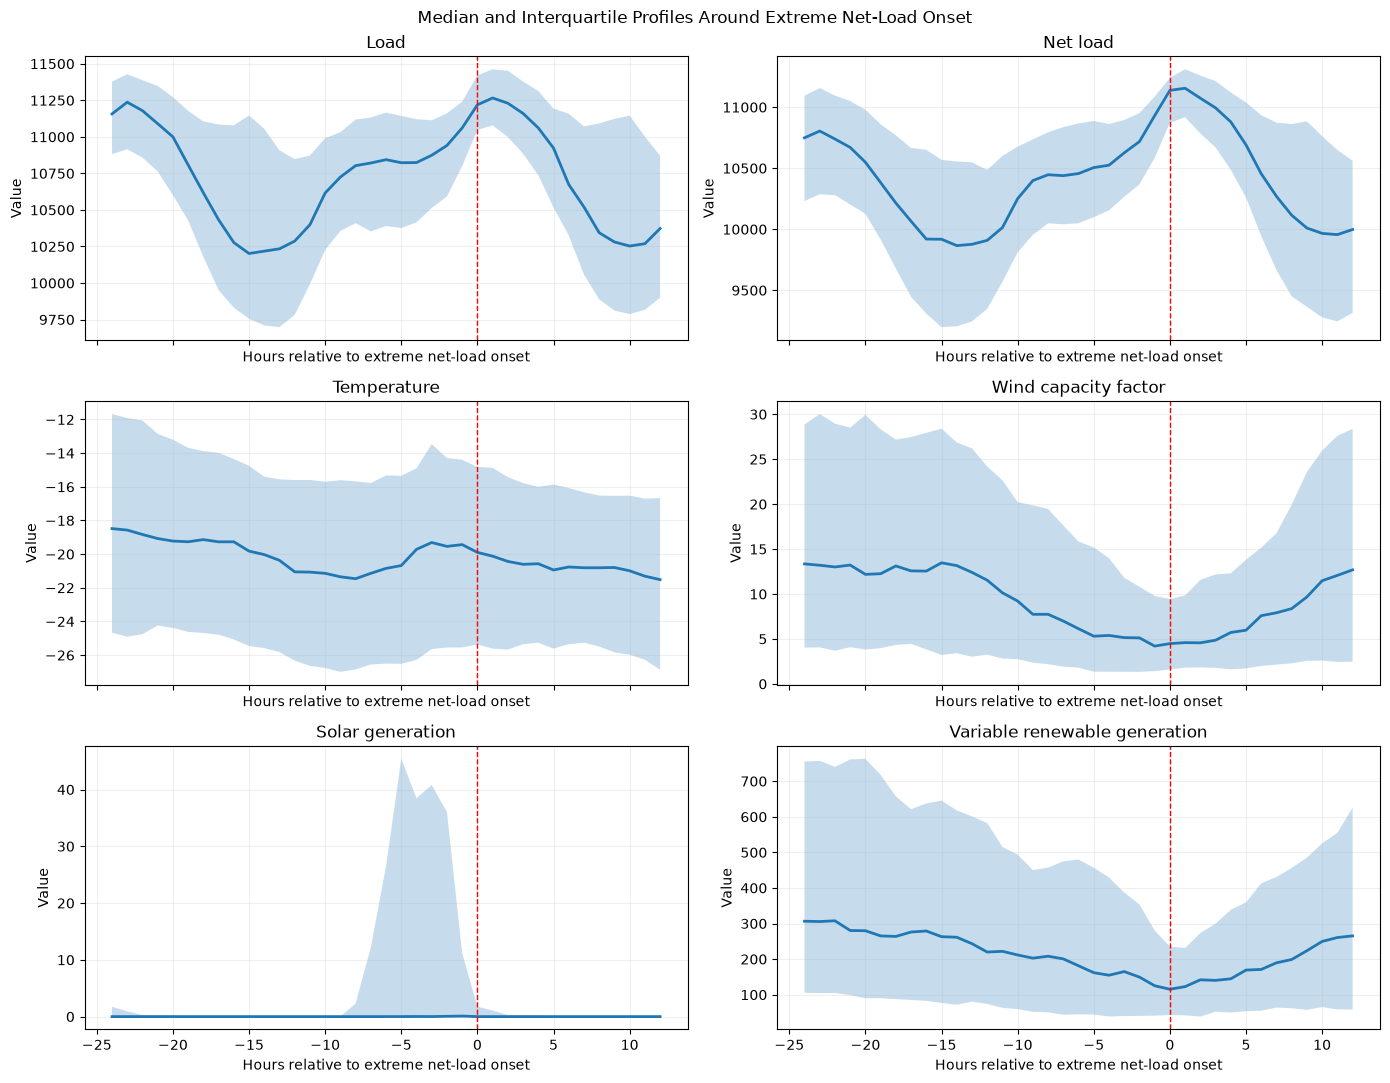

In [36]:
# ---------------------------------------------------------------------
# Plot event-aligned net-load profiles
# ---------------------------------------------------------------------

profile_variables = list(aligned_variables.keys())

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)

for axis, variable in zip(axes.flatten(), profile_variables):
    plot_data = event_aligned_profile.loc[
        event_aligned_profile["variable"].eq(variable)
    ]

    axis.plot(plot_data["relative_hour"], plot_data["median"], linewidth=2)
    axis.fill_between(
        plot_data["relative_hour"],
        plot_data["q25"],
        plot_data["q75"],
        alpha=0.25,
    )

    axis.axvline(0, color="red", linestyle="--", linewidth=1)
    axis.set_title(variable)
    axis.set_xlabel("Hours relative to extreme net-load onset")
    axis.set_ylabel("Value")
    axis.grid(alpha=0.20)

fig.suptitle("Median and Interquartile Profiles Around Extreme Net-Load Onset")

plt.tight_layout()
plt.show()


#### Event findings

The onset profiles show extreme net load emerging from the convergence of already-cold temperatures, declining wind production, and the daily increase in electricity demand. Median wind capacity factor falls from approximately 13% one day beforehand to about 4% at onset, while load rises toward 11,250 MW. Together, these movements push median net load above 11,100 MW.

Temperature is already severely cold well before onset and changes comparatively little at the event boundary, indicating that onset is not usually caused by a sudden temperature shock. Solar generation provides little median support because these episodes are concentrated in winter and frequently extend through non-daylight hours. After onset, load declines and wind output gradually recovers, allowing net load to ease.

The longest historical episodes exhibit the same pattern: persistent cold, very low wind capacity factors, limited solar generation, and elevated load. Extreme net load is therefore best understood as the culmination of a developing compound weather state rather than an isolated hourly shock.

#### Compound-weather summary

Extreme net load is most likely when extreme cold coincides with low wind output. This combination produces an event rate of 26.5%, compared with 6.5% under extreme cold and typical wind. During daylight, low solar output compounds the effect of low wind: the extreme-net-load rate rises from 2.4% with typical solar to 15.5% when both resources are weak.

These events reflect both sides of net-load formation. Relative to other hours, extreme hours have approximately 1,687 MW more load and 769 MW less variable renewable generation, together raising net load by roughly 2,457 MW. The cold–low-wind relationship persists across all structural regimes, indicating a stable physical pattern rather than a feature of one market period.

Before onset, wind capacity factor and total renewable generation decline while load rises toward its daily peak. Temperature is generally already very cold and changes comparatively little at the event boundary; solar provides limited support because many episodes occur during winter and non-daylight hours. The episodes therefore share a dominant pathway—persistent cold demand combined with weak wind—but differ in timing, duration, solar contribution, and the relative importance of demand growth versus renewable shortfall.

This section establishes how weather forms extreme net load. Its subsequent relationship with system tightness and price scarcity remains part of Notebook 2.

## 7. Evidence register

The evidence register classifies every weather and renewable driver using:

1. its physical mechanism;
2. the outcome it helps explain;
3. the relationship shape examined in this notebook;
4. its information timing;
5. its forecast-ready equivalent;
6. overlap with other variables; and
7. its final analytical destination.

Observed ERA5 weather may support historical explanation, but operational forecasting requires forecast-vintage weather. Actual load, generation, and net load remain realized outcomes.

In [37]:
# ---------------------------------------------------------------------
# Create the Notebook 4 evidence register
# ---------------------------------------------------------------------

evidence_register = pd.DataFrame([
    {
        "feature_family": "Load-weighted temperature",
        "mechanism": "Heating and cooling demand",
        "main_outcome": "Alberta load",
        "relationship_test": "Nonlinear binned response and annual stability",
        "timing_status": "ERA5 observed; actual regional load weights",
        "forecast_equivalent": "Temperature forecast with fixed or forecast regional weights",
        "redundant_with": "Heating/cooling degree and thermal-stress features",
        "final_classification": "Retain after forecast-weight redesign",
    },
    {
        "feature_family": "Humidity, wet bulb, wind chill and heat index",
        "mechanism": "Modification of thermal demand",
        "main_outcome": "Temperature-adjusted load",
        "relationship_test": "Residual association within temperature bins",
        "timing_status": "Observed ERA5-derived weather",
        "forecast_equivalent": "Forecast thermal-stress variables",
        "redundant_with": "Temperature and each other",
        "final_classification": "Conditional; retain only if incremental",
    },
    {
        "feature_family": "Temperature changes",
        "mechanism": "Rapid heating or cooling demand adjustment",
        "main_outcome": "Load ramps",
        "relationship_test": "Temperature-change state × temperature band",
        "timing_status": "Observed contemporaneous change",
        "forecast_equivalent": "Forecast temperature trajectory",
        "redundant_with": "Current temperature and forecast temperature path",
        "final_classification": "Conditional",
    },
    {
        "feature_family": "Capacity-weighted 100 m wind speed",
        "mechanism": "Wind resource available to the active fleet",
        "main_outcome": "Wind capacity factor",
        "relationship_test": "Empirical power curve and regime stability",
        "timing_status": "Observed ERA5 reanalysis",
        "forecast_equivalent": "Capacity-weighted wind forecast",
        "redundant_with": "Wind-speed powers and vector components",
        "final_classification": "Retain",
    },
    {
        "feature_family": "Wind spatial dispersion",
        "mechanism": "Geographic diversification of wind conditions",
        "main_outcome": "Aggregate wind ramps",
        "relationship_test": "Ramp magnitude across dispersion states",
        "timing_status": "Observed ERA5 reanalysis",
        "forecast_equivalent": "Spatial weather-forecast dispersion",
        "redundant_with": "Project-level wind forecasts",
        "final_classification": "Conditional",
    },
    {
        "feature_family": "Actual wind generation",
        "mechanism": "Realized variable renewable supply",
        "main_outcome": "Historical net load",
        "relationship_test": "Capacity factor, ramps and low-output states",
        "timing_status": "Observed after realization",
        "forecast_equivalent": "Wind-generation forecast",
        "redundant_with": "Wind capacity factor",
        "final_classification": "Descriptive only",
    },
    {
        "feature_family": "Capacity-weighted solar irradiance",
        "mechanism": "Solar resource available to the active fleet",
        "main_outcome": "Solar capacity factor",
        "relationship_test": "Daylight irradiance response and regime stability",
        "timing_status": "Observed ERA5 reanalysis",
        "forecast_equivalent": "Capacity-weighted irradiance forecast",
        "redundant_with": "Clear-sky ratio and direct radiation",
        "final_classification": "Retain",
    },
    {
        "feature_family": "Cloud cover and snow depth",
        "mechanism": "Reduction in available solar output",
        "main_outcome": "Solar capacity factor conditional on irradiance",
        "relationship_test": "Irradiance state × cloud or snow state",
        "timing_status": "Observed ERA5 reanalysis",
        "forecast_equivalent": "Cloud and snow forecasts",
        "redundant_with": "Irradiance and clear-sky ratio",
        "final_classification": "Conditional",
    },
    {
        "feature_family": "Actual solar generation",
        "mechanism": "Realized variable renewable supply",
        "main_outcome": "Historical net load",
        "relationship_test": "Capacity factor and daylight ramps",
        "timing_status": "Observed after realization",
        "forecast_equivalent": "Solar-generation forecast",
        "redundant_with": "Solar capacity factor",
        "final_classification": "Descriptive only",
    },
    {
        "feature_family": "Hydro generation and availability",
        "mechanism": "Dispatchable renewable supply",
        "main_outcome": "Historical supply conditions",
        "relationship_test": "Coverage and annual operating summary only",
        "timing_status": "Observed operational outcome",
        "forecast_equivalent": "Hydro availability or dispatch forecast",
        "redundant_with": "Hydro capacity factor and outages",
        "final_classification": "Defer weather attribution",
    },
    {
        "feature_family": "Actual net load",
        "mechanism": "Demand remaining after wind and solar",
        "main_outcome": "Extreme net-load conditions",
        "relationship_test": "Compound states and event-aligned profiles",
        "timing_status": "Known only after load and generation realize",
        "forecast_equivalent": "Load forecast minus wind and solar forecasts",
        "redundant_with": "Load and renewable-generation components",
        "final_classification": "Forecast-constructed only",
    },
])

display(evidence_register)


,feature_family,mechanism,main_outcome,relationship_test,timing_status,forecast_equivalent,redundant_with,final_classification
0,Load-weighted temperature,Heating and cooling demand,Alberta load,Nonlinear binned response and annual stability,ERA5 observed; actual regional load weights,Temperature forecast with fixed or forecast re...,Heating/cooling degree and thermal-stress feat...,Retain after forecast-weight redesign
1,"Humidity, wet bulb, wind chill and heat index",Modification of thermal demand,Temperature-adjusted load,Residual association within temperature bins,Observed ERA5-derived weather,Forecast thermal-stress variables,Temperature and each other,Conditional; retain only if incremental
2,Temperature changes,Rapid heating or cooling demand adjustment,Load ramps,Temperature-change state × temperature band,Observed contemporaneous change,Forecast temperature trajectory,Current temperature and forecast temperature path,Conditional
3,Capacity-weighted 100 m wind speed,Wind resource available to the active fleet,Wind capacity factor,Empirical power curve and regime stability,Observed ERA5 reanalysis,Capacity-weighted wind forecast,Wind-speed powers and vector components,Retain
4,Wind spatial dispersion,Geographic diversification of wind conditions,Aggregate wind ramps,Ramp magnitude across dispersion states,Observed ERA5 reanalysis,Spatial weather-forecast dispersion,Project-level wind forecasts,Conditional
5,Actual wind generation,Realized variable renewable supply,Historical net load,"Capacity factor, ramps and low-output states",Observed after realization,Wind-generation forecast,Wind capacity factor,Descriptive only
6,Capacity-weighted solar irradiance,Solar resource available to the active fleet,Solar capacity factor,Daylight irradiance response and regime stability,Observed ERA5 reanalysis,Capacity-weighted irradiance forecast,Clear-sky ratio and direct radiation,Retain
7,Cloud cover and snow depth,Reduction in available solar output,Solar capacity factor conditional on irradiance,Irradiance state × cloud or snow state,Observed ERA5 reanalysis,Cloud and snow forecasts,Irradiance and clear-sky ratio,Conditional
8,Actual solar generation,Realized variable renewable supply,Historical net load,Capacity factor and daylight ramps,Observed after realization,Solar-generation forecast,Solar capacity factor,Descriptive only
9,Hydro generation and availability,Dispatchable renewable supply,Historical supply conditions,Coverage and annual operating summary only,Observed operational outcome,Hydro availability or dispatch forecast,Hydro capacity factor and outages,Defer weather attribution


### 7.1 Evidence summary

The evidence supports temperature, capacity-weighted wind speed, and solar irradiance as the primary physical weather drivers. Each has a clear relationship with its corresponding outcome and a plausible forecast equivalent. However, the current fields are realized ERA5 observations and must be replaced with forecast-vintage weather using fixed or forecast-eligible geographic weights.

Temperature changes, humidity-related measures, wind dispersion, cloud cover, and snow depth are conditional candidates. They should be retained only if they add out-of-sample value beyond the primary weather variables. Wind chill and heat index show little incremental historical association, while cloud cover provides clearer additional information for solar output.

Actual load, wind generation, solar generation, and net load are realized outcomes rather than contemporaneous forecast inputs. Operational models must replace them with forecasts or lagged values, with future net load constructed from separate load, wind, and solar forecasts. Hydro weather attribution remains deferred because the required reservoir, inflow, watershed, and operational data are unavailable.

### 7.2 Deferred analyses

| Driver family | Destination | Reason |
|---|---|---|
| Scarcity rates, available margin and outages | Notebook 2 | Physical system-tightness outcomes |
| Gas prices and marginal-generation economics | Notebook 3 | Fuel-cost and price-formation mechanisms |
| Hour, weekday, holiday and recurring calendar effects | Notebook 5 | Temporal structure |
| Price lags and volatility clustering | Notebook 5 | Market memory |
| Weather-forecast errors | Notebooks 6–8 or future extension | Requires archived forecast vintages |
| Load, wind and solar predictive models | Notebooks 6–8 | Requires time-based model validation |
| Hydro weather attribution | Future extension | Requires inflows, reservoir levels and watershed data |
| Formal feature selection | Notebooks 6–8 | Must be evaluated out of sample |

Notebook 4 may use actual load and renewable generation to explain historical net-load formation. It must not describe realized values as operational forecast signals.

## 8. Conclusion

This notebook examined how weather shapes Alberta electricity demand, renewable generation, and net load over 2015–2025.

**Demand formation.** Alberta load has a strong and stable U-shaped relationship with temperature. Demand is lowest near 9–11°C, at approximately 92% of the annual median, and rises toward 112% during both extreme cold and extreme heat. Cold sensitivity is broader and supported by more observations, while hot-weather demand increases sharply above 20°C. This pattern persists across years after normalizing for annual load levels. Six-hour temperature change adds descriptive information beyond temperature level, although part of its relationship with load ramps likely reflects the daily demand cycle.

**Wind availability.** Capacity-weighted 100 m wind speed has a clear nonlinear relationship with realized wind capacity factor. Median capacity factor rises rapidly through moderate wind speeds and plateaus near 75–80% under stronger conditions. The relationship persists across structural regimes, but the same measured wind speed corresponds to lower capacity factors in later periods. This may reflect changes in fleet geography, turbine composition, curtailment, outages, capacity timing, or weather-weight representativeness. Low-wind events are usually brief—the median duration is four hours—but have a meaningful persistence tail: 1% last at least 23 hours, and the longest continues for 58 hours.

**Solar availability.** Solar irradiance has a strong, nearly monotonic relationship with daylight capacity factor, which rises from near zero under minimal radiation to approximately 88% near 900 W/m². The relationship remains broadly stable as the fleet expands. Cloud cover adds substantial information within comparable irradiance conditions: in the highest irradiance decile, median capacity factor falls from 83% under low cloud to 52% under high cloud. Snow is associated with reductions of roughly 4–7 percentage points at higher irradiance, but its relationship is less consistent under weak sunlight. Solar ramps are large over multi-hour horizons, although much of this movement follows predictable sunrise and sunset transitions.

**Compound conditions.** Extreme net load is concentrated when cold-driven demand coincides with weak renewable generation. Extreme cold combined with low wind produces a top-1% net-load rate of 26.5%, compared with 6.5% under extreme cold and typical wind. During daylight, the rate reaches 15.5% when both wind and solar output are low, compared with 2.4% when low wind is accompanied by typical solar output. Relative to other hours, extreme net-load hours have approximately 1,687 MW more load and 769 MW less variable renewable generation, producing a combined net-load increase of roughly 2,457 MW. This cold–low-wind pathway persists across structural regimes and develops through rising load and declining wind output rather than a sudden temperature shock at onset.

**Forecast handoff.** Temperature, wind speed, irradiance, cloud cover, snow depth, and forecast temperature trajectories have plausible equivalents in numerical weather forecasts. Their current ERA5 values remain realized historical observations, however, and must be replaced with forecast-vintage weather using fixed or forecast-eligible geographic weights. Actual load, wind generation, solar generation, and net load are realized outcomes; forecasting must replace them with lagged observations or separate load and renewable forecasts. Hydro weather attribution remains deferred because reservoir, inflow, watershed, and operational-dispatch data are unavailable.

The evidence register therefore retains temperature, wind speed, and irradiance as primary forecast candidates; treats secondary weather modifiers as conditional; classifies realized load and renewable generation as descriptive outcomes; and defines net load as a forecast-constructed variable. Notebook 5 next examines recurring temporal structure and market memory, while Notebooks 6–8 determine whether these physical relationships improve out-of-sample forecasts under time-based, regime-aware validation.